# KRITIS–Philippines: Typhoon × Grid Disruption Screening

## Objective

This notebook implements a first-pass **topological screening model** of typhoon-induced grid disruption in the Philippines.

Historical typhoon track points from **IBTrACS** are translated into stylized line hazards on a **PyPSA-PH** transmission network. Lines exceeding a hazard threshold are assumed to fail. Buses that are no longer connected to any generator-containing network component are treated as **unserved**. Population within a fixed radius around those unserved buses is summed as an **affected-population proxy**.

## What this notebook does

- loads historical typhoon track points intersecting the Philippines domain
- loads a static PyPSA-PH transmission network
- loads WorldPop population data
- computes a stylized wind-distance hazard for each line
- samples multiple points along each transmission line
- applies a threshold failure rule
- removes failed lines from the graph
- identifies buses disconnected from generation
- tracks disruption through storm time
- ranks storms by implied grid-service disruption

## Interpretation

This is a **comparative stress-test on a common benchmark network**, not a reconstruction of the exact historical infrastructure in each storm year.

Key simplifications:
- the transmission network is treated as static
- population is fixed to one contemporary raster
- line hazard is based on sampled points along each transmission line
- failure is threshold-based, not probabilistic
- service is based on graph connectivity, not electrical load flow

**Imports and configuration**

In [112]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, HTML

import networkx as nx
from tropycal import tracks
from scipy.spatial import cKDTree

REPO_ROOT = Path.cwd().resolve()

BUSES_CSV = REPO_ROOT / "PyPSA-PH/data/buses.csv"
LINES_CSV = REPO_ROOT / "PyPSA-PH/data/lines.csv"
GENERATORS_CSV = REPO_ROOT / "PyPSA-PH/data/generators.csv"
WORLDPOP_CSV = REPO_ROOT / "data/worldpop_ph_2020_1km/phl_pd_2020_1km_ASCII_XYZ.csv"

OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2000

PH_BOUNDS = {
    "lat_min": 4.0,
    "lat_max": 22.0,
    "lon_min": 116.0,
    "lon_max": 128.0,
}

SEARCH_RADIUS_KM = 200.0
DECAY_KM = 40.0
FAIL_THRESHOLD = 0.55
BUS_POP_RADIUS_KM = 50.0
LINE_SAMPLE_POINTS = 7

USE_GENERATOR_COMMISSION_YEAR = False
GENERATOR_YEAR_COLUMN = "commissioning_year"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("REPO_ROOT:", REPO_ROOT)

Python: 3.12.3
REPO_ROOT: /home/krawalker/coding/KRITIS-PH


**Helper functions**

In [69]:
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2.0 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c


def storm_name_map_from_ib(ib_ds):
    out = {}
    for sid, storm in ib_ds.data.items():
        name = storm.get("name")
        if name is None or str(name).strip() == "":
            name = "UNNAMED"
        out[str(sid)] = str(name).upper()
    return out


def minmax_normalize(series):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)

**Add a helper to project lat/lon to approximate km space**

In [113]:
def latlon_to_km_xy(lat, lon, lat_ref=None):
    """
    Approximate conversion of lat/lon to local Cartesian km coordinates.

    Good enough for nearest-neighbour assignment over the Philippines domain.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)

    if lat_ref is None:
        lat_ref = np.nanmean(lat)

    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(lat_ref))

    x = lon * km_per_deg_lon
    y = lat * km_per_deg_lat
    return x, y

**Add the nearest-bus population assignment helper**

In [114]:
def assign_population_to_nearest_bus(pop_ph, buses):
    """
    Assign each population cell to exactly one nearest bus.

    Returns
    -------
    buses_out : DataFrame
        Original buses table with a new column:
        - bus_pop_local_nb : uniquely assigned local population
    pop_assignment : DataFrame
        Population cells with assigned nearest bus
    """
    if pop_ph.empty:
        raise ValueError("pop_ph is empty.")
    if buses.empty:
        raise ValueError("buses is empty.")

    buses_out = buses.copy()

    lat_ref = np.nanmean(
        np.concatenate([
            pop_ph["lat"].to_numpy(dtype=float),
            buses["lat"].to_numpy(dtype=float),
        ])
    )

    bus_x, bus_y = latlon_to_km_xy(
        buses_out["lat"].to_numpy(),
        buses_out["lon"].to_numpy(),
        lat_ref=lat_ref,
    )

    pop_x, pop_y = latlon_to_km_xy(
        pop_ph["lat"].to_numpy(),
        pop_ph["lon"].to_numpy(),
        lat_ref=lat_ref,
    )

    tree = cKDTree(np.column_stack([bus_x, bus_y]))
    dist_km, idx = tree.query(np.column_stack([pop_x, pop_y]), k=1)

    pop_assignment = pop_ph.copy()
    pop_assignment["nearest_bus_idx"] = idx.astype(int)
    pop_assignment["nearest_bus_dist_km"] = dist_km.astype(float)
    pop_assignment["nearest_bus_id"] = buses_out.iloc[idx]["bus_id"].to_numpy()

    bus_pop_nb = (
        pop_assignment.groupby("nearest_bus_id", as_index=False)["pop_value"]
        .sum()
        .rename(columns={
            "nearest_bus_id": "bus_id",
            "pop_value": "bus_pop_local_nb",
        })
    )

    buses_out = buses_out.merge(bus_pop_nb, on="bus_id", how="left")
    buses_out["bus_pop_local_nb"] = buses_out["bus_pop_local_nb"].fillna(0.0)

    return buses_out, pop_assignment

**Load and filter IBTrACS storm points**

In [70]:
ib = tracks.TrackDataset(basin="west_pacific", source="ibtracs")
name_map = storm_name_map_from_ib(ib)

rows = []

for storm_id, storm in ib.data.items():
    year = storm.get("year", storm.get("season"))
    if year is None:
        continue

    try:
        year = int(year)
    except (TypeError, ValueError):
        continue

    if year < START_YEAR:
        continue

    lat_list = storm.get("lat", [])
    lon_list = storm.get("lon", [])
    vmax_list = storm.get("vmax", [])
    time_list = storm.get("time", [])

    n_points = min(len(lat_list), len(lon_list), len(vmax_list))

    for point_index in range(n_points):
        lat = lat_list[point_index]
        lon = lon_list[point_index]
        vmax_kt = vmax_list[point_index]
        time = time_list[point_index] if point_index < len(time_list) else None

        if lat is None or lon is None or vmax_kt is None:
            continue

        try:
            lat = float(lat)
            lon = float(lon)
            vmax_kt = float(vmax_kt)
        except (TypeError, ValueError):
            continue

        if lon < 0:
            lon += 360

        in_box = (
            PH_BOUNDS["lat_min"] <= lat <= PH_BOUNDS["lat_max"]
            and PH_BOUNDS["lon_min"] <= lon <= PH_BOUNDS["lon_max"]
        )
        if not in_box:
            continue

        rows.append(
            {
                "storm_id": str(storm_id),
                "storm_name": name_map.get(str(storm_id), "UNNAMED"),
                "year": year,
                "point_index": point_index,
                "time": time,
                "lat": lat,
                "lon": lon,
                "wind_kt": vmax_kt,
                "wind_kph": vmax_kt * 1.852,
            }
        )

ph_points = (
    pd.DataFrame(rows)
    .sort_values(["storm_id", "point_index"])
    .reset_index(drop=True)
)

if ph_points.empty:
    raise ValueError("No storm points found in PH domain.")

ph_points["t"] = ph_points.groupby("storm_id").cumcount()

print("Track points in PH box:", len(ph_points))
print("Unique storms:", ph_points["storm_id"].nunique())
display(ph_points.head())

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (20.11 seconds)
Track points in PH box: 3361
Unique storms: 323


,storm_id,storm_name,year,point_index,time,lat,lon,wind_kt,wind_kph,t
0,WP012001,UNNAMED,2001,6,2001-02-17 18:00:00,10.2,127.0,20.0,37.04,0
1,WP012001,UNNAMED,2001,7,2001-02-18 00:00:00,10.5,125.9,25.0,46.30,1
2,WP012001,UNNAMED,2001,8,2001-02-18 06:00:00,10.9,124.8,25.0,46.30,2
3,WP012001,UNNAMED,2001,9,2001-02-18 12:00:00,11.2,123.9,25.0,46.30,3
4,WP012001,UNNAMED,2001,10,2001-02-18 18:00:00,11.3,123.3,25.0,46.30,4


**Load buses, lines, generators**

In [73]:
buses = (
    pd.read_csv(BUSES_CSV)
    .rename(columns={"name": "bus_id", "x": "lon", "y": "lat"})
    .copy()
)

for c in ["lon", "lat", "v_nom"]:
    if c in buses.columns:
        buses[c] = pd.to_numeric(buses[c], errors="coerce")

buses = buses.dropna(subset=["bus_id", "lon", "lat"]).copy()
buses["bus_id"] = buses["bus_id"].astype(str)

lines = pd.read_csv(LINES_CSV).copy()
lines["bus0"] = lines["bus0"].astype(str)
lines["bus1"] = lines["bus1"].astype(str)

generators = pd.read_csv(GENERATORS_CSV).copy()
if "bus" in generators.columns:
    generators["bus"] = generators["bus"].astype(str)

print("Buses:", len(buses))
print("Lines:", len(lines))
print("Generators:", len(generators))

display(buses.head())
display(lines.head())
display(generators.head())

Buses: 192
Lines: 236
Generators: 425


,bus_id,lon,lat,v_nom
0,01AMBKLAO,120.741167,16.458580,230
1,01ANGAT,121.030976,14.922529,230
2,01ANGSJO_TP2,121.166303,14.907693,115
3,01ANGSJO_TP4,121.166303,14.907693,115
4,01BAKUN,120.823858,16.763519,230


,name,cables,bus0,bus1,s_nom,x,r
0,115_01BNTAY_01CURIMAO,1,01BNTAY,01CURIMAO,115.0,10.669251,5.109878
1,115_01BNTAY_01SNESTBN,1,01BNTAY,01SNESTBN,115.0,6.439971,3.084327
2,115_01CURIMAO_01LAOAG,1,01CURIMAO,01LAOAG,115.0,5.641781,2.702046
3,115_01LAOAG_01PASUQUIN,1,01LAOAG,01PASUQUIN,115.0,3.341738,1.600475
4,115_01LAOAG_01BURGOS,1,01LAOAG,01BURGOS,115.0,38.691844,18.530878


,name,bus,p_nom,carrier,build_year
0,01ACNPC_G01,01CNCEPCN,3.2,Biomass,2017
1,01AMBUK_U01,01AMBKLAO,37.5,Hydro,1956
2,01AMBUK_U02,01AMBKLAO,37.5,Hydro,1956
3,01AMBUK_U03,01AMBKLAO,37.5,Hydro,1956
4,01AMPHAW_G01,01LATRINI,12.5,Hydro,1991


**Build line geometry and base graph**

In [74]:
line_df = lines.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus0",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat0", "lon": "lon0"}).drop(columns=["bus_id"])

line_df = line_df.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus1",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat1", "lon": "lon1"}).drop(columns=["bus_id"])

line_df = line_df.dropna(subset=["lat0", "lon0", "lat1", "lon1"]).copy()
line_df["lat_mid"] = (line_df["lat0"] + line_df["lat1"]) / 2.0
line_df["lon_mid"] = (line_df["lon0"] + line_df["lon1"]) / 2.0
line_df["line_id"] = np.arange(len(line_df)).astype(str)

G_base = nx.Graph()

for _, b in buses.iterrows():
    G_base.add_node(b["bus_id"])

for _, l in line_df.iterrows():
    G_base.add_edge(l["bus0"], l["bus1"], line_id=l["line_id"])

print("Graph nodes:", G_base.number_of_nodes())
print("Graph edges:", G_base.number_of_edges())

Graph nodes: 192
Graph edges: 233


**Build sampled points along each line**

In [76]:
def build_line_samples(line_df, n_samples=7):
    sample_rows = []

    for _, row in line_df.iterrows():
        lats = np.linspace(row["lat0"], row["lat1"], n_samples)
        lons = np.linspace(row["lon0"], row["lon1"], n_samples)

        for sample_idx, (lat, lon) in enumerate(zip(lats, lons)):
            sample_rows.append(
                {
                    "line_id": str(row["line_id"]),
                    "bus0": row["bus0"],
                    "bus1": row["bus1"],
                    "sample_idx": int(sample_idx),
                    "lat": float(lat),
                    "lon": float(lon),
                }
            )

    line_samples = pd.DataFrame(sample_rows)
    return line_samples


line_samples = build_line_samples(line_df, n_samples=LINE_SAMPLE_POINTS)

print("Number of lines:", len(line_df))
print("Number of line sample points:", len(line_samples))
display(line_samples.head(15))

Number of lines: 236
Number of line sample points: 1652


,line_id,bus0,bus1,sample_idx,lat,lon
0,0,01BNTAY,01CURIMAO,0,17.595321,120.391359
1,0,01BNTAY,01CURIMAO,1,17.663854,120.411670
2,0,01BNTAY,01CURIMAO,2,17.732388,120.431982
3,0,01BNTAY,01CURIMAO,3,17.800921,120.452293
4,0,01BNTAY,01CURIMAO,4,17.869455,120.472604
5,0,01BNTAY,01CURIMAO,5,17.937988,120.492915
6,0,01BNTAY,01CURIMAO,6,18.006522,120.513227
7,1,01BNTAY,01SNESTBN,0,17.595321,120.391359
8,1,01BNTAY,01SNESTBN,1,17.553266,120.400668
9,1,01BNTAY,01SNESTBN,2,17.511211,120.409977


**QC plot for sampled line points**

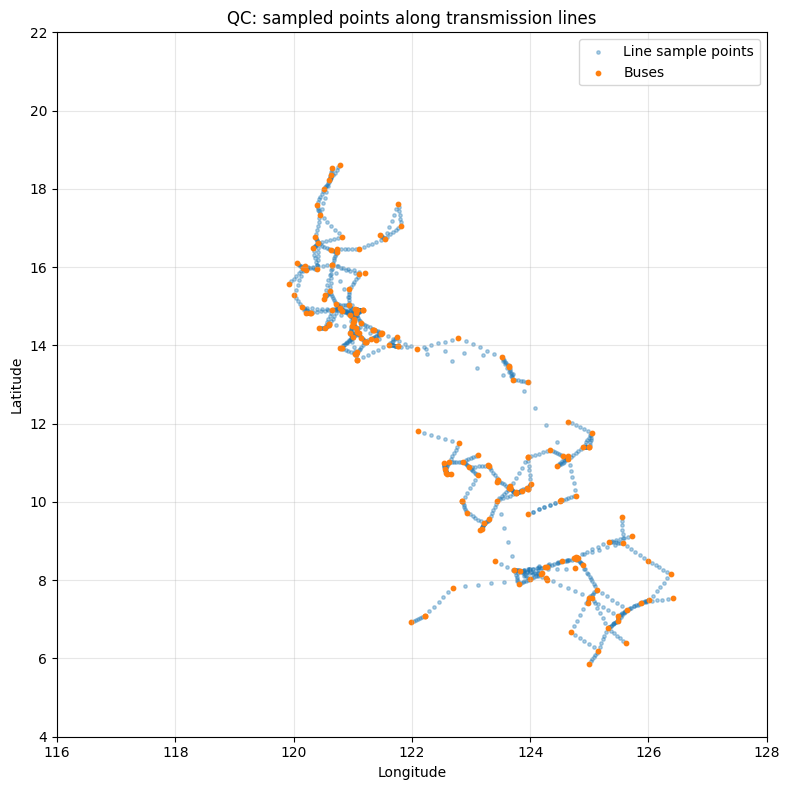

In [77]:
fig, ax = plt.subplots(figsize=(8, 8))

sample_plot = line_samples.sample(min(len(line_samples), 3000), random_state=RANDOM_SEED)

ax.scatter(
    sample_plot["lon"],
    sample_plot["lat"],
    s=6,
    alpha=0.35,
    label="Line sample points",
)

ax.scatter(
    buses["lon"],
    buses["lat"],
    s=10,
    label="Buses",
)

ax.set_xlim(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
ax.set_ylim(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
ax.set_title("QC: sampled points along transmission lines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Load WorldPop and attach local population to buses**

In [78]:
def load_worldpop_xyz(path):
    try:
        df = pd.read_csv(path)
        if df.shape[1] < 3:
            raise ValueError
    except Exception:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            header=None,
            names=["lon", "lat", "pop_value"],
            engine="python",
            comment="#",
        )

    if list(df.columns)[:3] != ["lon", "lat", "pop_value"]:
        df = df.iloc[:, :3].copy()
        df.columns = ["lon", "lat", "pop_value"]

    for c in ["lon", "lat", "pop_value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["lon", "lat", "pop_value"]).copy()

    if (df["lon"] < 0).any():
        df.loc[df["lon"] < 0, "lon"] += 360

    return df


worldpop = load_worldpop_xyz(WORLDPOP_CSV)

pop_ph = worldpop[
    worldpop["lat"].between(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
    & worldpop["lon"].between(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
    & (worldpop["pop_value"] > 0)
].copy()

pop_lat = pop_ph["lat"].to_numpy()
pop_lon = pop_ph["lon"].to_numpy()
pop_val = pop_ph["pop_value"].to_numpy()

bus_pop_vals = []

for _, b in buses.iterrows():
    d = haversine_km(pop_lat, pop_lon, b["lat"], b["lon"])
    bus_pop_vals.append(pop_val[d <= BUS_POP_RADIUS_KM].sum())

buses["bus_pop_local"] = bus_pop_vals

print("Population rows in PH box:", len(pop_ph))
display(buses[["bus_id", "lat", "lon", "bus_pop_local"]].head())

Population rows in PH box: 372755


,bus_id,lat,lon,bus_pop_local
0,01AMBKLAO,16.458580,120.741167,3.005067e+06
1,01ANGAT,14.922529,121.030976,2.487936e+07
2,01ANGSJO_TP2,14.907693,121.166303,2.340978e+07
3,01ANGSJO_TP4,14.907693,121.166303,2.340978e+07
4,01BAKUN,16.763519,120.823858,2.150979e+06


In [115]:
buses_nb, pop_assignment = assign_population_to_nearest_bus(pop_ph=pop_ph, buses=buses)

print("Population rows in PH box:", len(pop_ph))
print("Population rows assigned:", len(pop_assignment))
print("Unique buses receiving population:", (buses_nb["bus_pop_local_nb"] > 0).sum())

display(
    buses_nb[
        ["bus_id", "lat", "lon", "bus_pop_local_nb"]
    ].sort_values("bus_pop_local_nb", ascending=False).head(15)
)

Population rows in PH box: 372755
Population rows assigned: 372755
Unique buses receiving population: 187


,bus_id,lat,lon,bus_pop_local_nb
59,02QUEZON,14.665666,121.021695,5.562161e+06
145,08NABAS,11.814408,122.095481,4.499376e+06
152,09PITOG,6.940741,121.991801,4.008819e+06
55,02DOLORES,14.572693,121.141174,3.957143e+06
191,14TACUR,6.669240,124.687087,3.408102e+06
60,02ZAPOTE,14.484570,120.987479,3.117837e+06
71,03DASMAEHV,14.312346,120.951042,2.968677e+06
57,02MANILA,14.580731,120.999348,2.783354e+06
56,02DONAIMELDA,14.622157,121.015571,2.621333e+06
26,01EHVSJOS,14.821626,121.048310,2.393120e+06


**Quick QC comparison old vs new population logic**

,bus_id,bus_pop_local,bus_pop_local_nb
59,02QUEZON,3.178074e+07,5.562161e+06
145,08NABAS,1.298295e+06,4.499376e+06
152,09PITOG,1.831712e+06,4.008819e+06
55,02DOLORES,3.210079e+07,3.957143e+06
191,14TACUR,2.564360e+06,3.408102e+06
60,02ZAPOTE,3.261036e+07,3.117837e+06
71,03DASMAEHV,3.017689e+07,2.968677e+06
57,02MANILA,3.245986e+07,2.783354e+06
56,02DONAIMELDA,3.228250e+07,2.621333e+06
26,01EHVSJOS,2.790607e+07,2.393120e+06


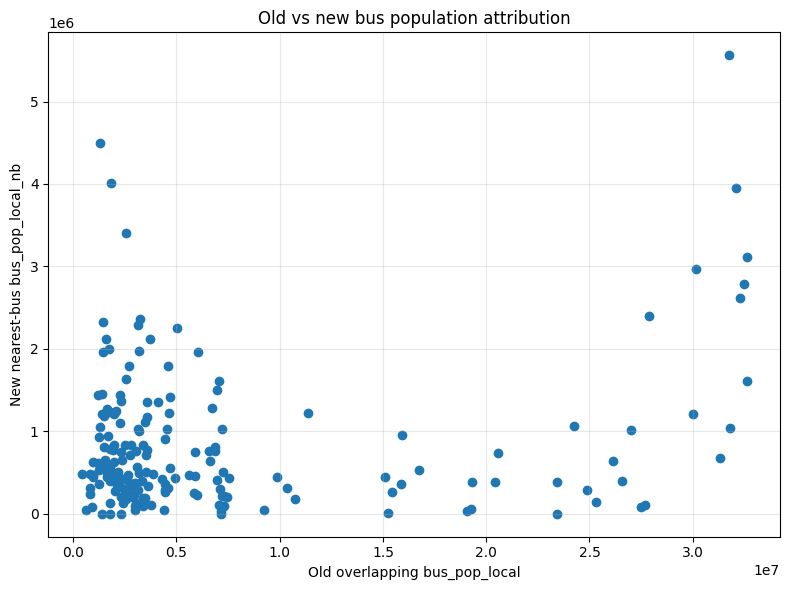

Old total assigned population (overlapping): 1351340186.1247852
New total assigned population (nearest-bus, unique): 154555312.94631407
True total population in pop_ph: 154555312.94631407


In [116]:
bus_pop_compare = buses[["bus_id", "bus_pop_local"]].merge(
    buses_nb[["bus_id", "bus_pop_local_nb"]],
    on="bus_id",
    how="outer",
)

bus_pop_compare["bus_pop_local"] = bus_pop_compare["bus_pop_local"].fillna(0.0)
bus_pop_compare["bus_pop_local_nb"] = bus_pop_compare["bus_pop_local_nb"].fillna(0.0)

display(bus_pop_compare.sort_values("bus_pop_local_nb", ascending=False).head(20))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(bus_pop_compare["bus_pop_local"], bus_pop_compare["bus_pop_local_nb"])
ax.set_xlabel("Old overlapping bus_pop_local")
ax.set_ylabel("New nearest-bus bus_pop_local_nb")
ax.set_title("Old vs new bus population attribution")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Old total assigned population (overlapping):", buses["bus_pop_local"].sum())
print("New total assigned population (nearest-bus, unique):", buses_nb["bus_pop_local_nb"].sum())
print("True total population in pop_ph:", pop_ph["pop_value"].sum())

**Generator selection helper**

In [79]:
def get_generator_buses_for_storm_year(
    generators,
    graph_nodes,
    storm_year,
    use_commission_year=False,
    year_col="commissioning_year",
):
    g = generators.copy()

    if use_commission_year and year_col in g.columns:
        g[year_col] = pd.to_numeric(g[year_col], errors="coerce")
        g = g[g[year_col].isna() | (g[year_col] <= storm_year)].copy()

    gen_buses = set(g["bus"].dropna().astype(str)) & set(graph_nodes)
    return gen_buses

**Quick map QC**

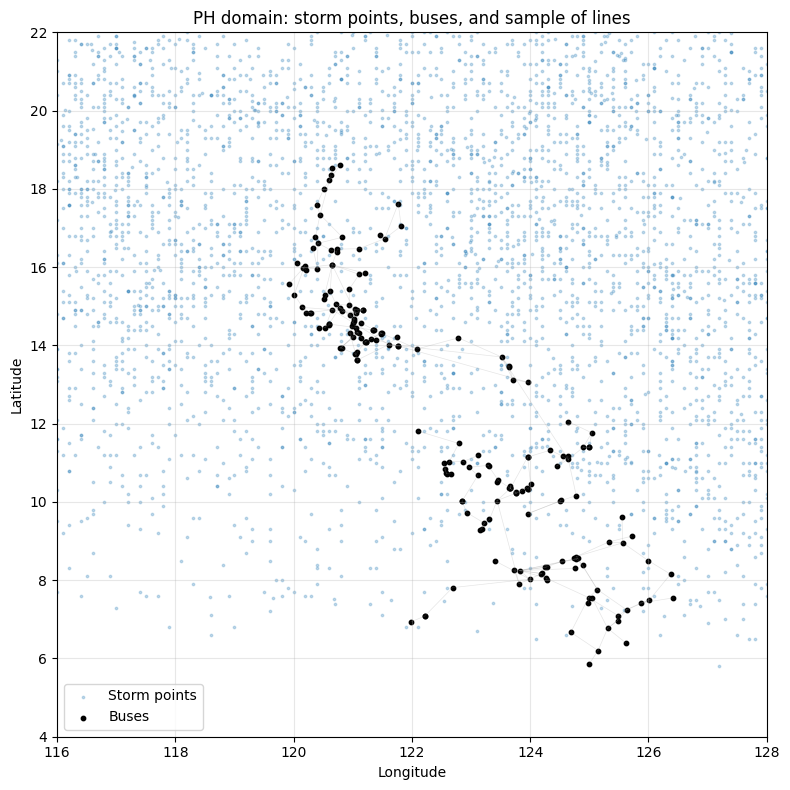

In [81]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    ph_points["lon"],
    ph_points["lat"],
    s=3,
    alpha=0.25,
    label="Storm points",
)

ax.scatter(
    buses["lon"],
    buses["lat"],
    s=10,
    color="black",
    label="Buses",
)

sample_n = min(len(line_df), 500)
for _, l in line_df.sample(sample_n, random_state=RANDOM_SEED).iterrows():
    ax.plot(
        [l["lon0"], l["lon1"]],
        [l["lat0"], l["lat1"]],
        color="gray",
        alpha=0.2,
        linewidth=0.5,
    )

ax.set_xlim(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
ax.set_ylim(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
ax.set_title("PH domain: storm points, buses, and sample of lines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Global wind normalization**

In [82]:
GLOBAL_MAX_WIND = ph_points["wind_kph"].max()
if pd.isna(GLOBAL_MAX_WIND) or GLOBAL_MAX_WIND <= 0:
    GLOBAL_MAX_WIND = 1.0

print("GLOBAL_MAX_WIND:", GLOBAL_MAX_WIND)

GLOBAL_MAX_WIND: 314.84000000000003


In [98]:
RMAX_KM_DEFAULT = 35.0
RMAX_SCALING = False
INNER_CORE_FLOOR = 0.85
OUTER_DECAY_POWER = 1.35
MIN_EFFECTIVE_WIND_KPH = 30.0

**Hazard function for one storm timestep using sampled lines**

In [83]:
def compute_line_hazard_up_to_t_sampled(
    storm_points_up_to_t,
    line_samples,
    line_df,
    decay_km,
    search_radius_km,
    global_max_wind_kph,
):
    sample_hmax = np.zeros(len(line_samples), dtype=float)

    sample_lat = line_samples["lat"].to_numpy()
    sample_lon = line_samples["lon"].to_numpy()

    for _, sp in storm_points_up_to_t.iterrows():
        d = haversine_km(sample_lat, sample_lon, sp["lat"], sp["lon"])
        near = d <= search_radius_km

        if not np.any(near):
            continue

        wind_norm = float(sp["wind_kph"] / global_max_wind_kph)
        hz = wind_norm * np.exp(-d[near] / decay_km)

        sample_hmax[near] = np.maximum(sample_hmax[near], hz)

    sample_result = line_samples.copy()
    sample_result["hazard_sample_max"] = sample_hmax

    line_hazard = (
        sample_result.groupby("line_id", as_index=False)["hazard_sample_max"]
        .max()
        .rename(columns={"hazard_sample_max": "hazard_max"})
    )

    lf = line_df.merge(line_hazard, on="line_id", how="left")
    lf["hazard_max"] = lf["hazard_max"].fillna(0.0)

    return lf, sample_result

In [99]:
def radial_wind_factor(distance_km, rmax_km=35.0, inner_core_floor=0.85, outer_decay_power=1.35):
    d = np.asarray(distance_km, dtype=float)
    d = np.maximum(d, 0.0)

    rmax_km = max(float(rmax_km), 1.0)
    out = np.zeros_like(d, dtype=float)

    inner = d <= rmax_km
    outer = ~inner

    if np.any(inner):
        x = d[inner] / rmax_km
        out[inner] = inner_core_floor + (1.0 - inner_core_floor) * x

    if np.any(outer):
        x = d[outer] / rmax_km
        out[outer] = x ** (-outer_decay_power)

    return np.clip(out, 0.0, 1.0)


def estimate_rmax_km_from_point(storm_point, default_rmax_km=35.0, scaling=False):
    if not scaling:
        return float(default_rmax_km)

    wind_kph = float(storm_point.get("wind_kph", np.nan))
    if not np.isfinite(wind_kph):
        return float(default_rmax_km)

    rmax = default_rmax_km + 0.08 * max(wind_kph - 120.0, 0.0)
    return float(np.clip(rmax, 20.0, 80.0))

In [100]:
def compute_line_hazard_up_to_t_sampled_v4(
    storm_points_up_to_t,
    line_samples,
    line_df,
    search_radius_km,
    global_max_wind_kph,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
):
    sample_hmax = np.zeros(len(line_samples), dtype=float)

    sample_lat = line_samples["lat"].to_numpy()
    sample_lon = line_samples["lon"].to_numpy()

    for _, sp in storm_points_up_to_t.iterrows():
        wind_kph = float(sp["wind_kph"])
        if not np.isfinite(wind_kph) or wind_kph < min_effective_wind_kph:
            continue

        d = haversine_km(sample_lat, sample_lon, sp["lat"], sp["lon"])
        near = d <= search_radius_km

        if not np.any(near):
            continue

        rmax_km = estimate_rmax_km_from_point(
            storm_point=sp,
            default_rmax_km=rmax_km_default,
            scaling=rmax_scaling,
        )

        wind_norm = wind_kph / global_max_wind_kph
        radial_factor = radial_wind_factor(
            distance_km=d[near],
            rmax_km=rmax_km,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
        )

        hz = wind_norm * radial_factor
        sample_hmax[near] = np.maximum(sample_hmax[near], hz)

    sample_result = line_samples.copy()
    sample_result["hazard_sample_max"] = sample_hmax

    line_hazard = (
        sample_result.groupby("line_id", as_index=False)["hazard_sample_max"]
        .max()
        .rename(columns={"hazard_sample_max": "hazard_max"})
    )

    lf = line_df.merge(line_hazard, on="line_id", how="left")
    lf["hazard_max"] = lf["hazard_max"].fillna(0.0)

    return lf, sample_result

**Simulate one storm through time**

In [84]:
def simulate_grid_impact_timeseries_v3(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_buses,
    decay_km,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )

    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            decay_km=decay_km,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold

        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids

        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        served_buses = set()
        for comp in nx.connected_components(G_t):
            if len(set(comp) & gen_buses) > 0:
                served_buses |= set(comp)

        all_buses = set(G_t.nodes())
        unserved_buses = all_buses - served_buses

        bus_state = buses[["bus_id", "lat", "lon", "bus_pop_local"]].copy()
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = bus_state.loc[bus_state["unserved"], "bus_pop_local"].sum()
        total_population_proxy = bus_state["bus_pop_local"].sum()

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": float(affected_population),
            "affected_population_share_proxy": (
                float(affected_population) / float(total_population_proxy)
                if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }

        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "record": rec.copy(),
            }
        )

    ts_df = pd.DataFrame(records)
    return ts_df, step_outputs

In [101]:
def simulate_grid_impact_timeseries_v4(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_buses,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )

    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold

        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids

        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        served_buses = set()
        for comp in nx.connected_components(G_t):
            if len(set(comp) & gen_buses) > 0:
                served_buses |= set(comp)

        all_buses = set(G_t.nodes())
        unserved_buses = all_buses - served_buses

        bus_state = buses[["bus_id", "lat", "lon", "bus_pop_local"]].copy()
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = bus_state.loc[bus_state["unserved"], "bus_pop_local"].sum()
        total_population_proxy = bus_state["bus_pop_local"].sum()

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": float(affected_population),
            "affected_population_share_proxy": (
                float(affected_population) / float(total_population_proxy)
                if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }

        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "record": rec.copy(),
            }
        )

    ts_df = pd.DataFrame(records)
    return ts_df, step_outputs

**Build a v4b simulation function that uses the new population column**

In [117]:
def simulate_grid_impact_timeseries_v4b(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_buses,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )

    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    if bus_pop_col not in buses.columns:
        raise ValueError(f"'{bus_pop_col}' not found in buses columns.")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold

        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids

        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        served_buses = set()
        for comp in nx.connected_components(G_t):
            if len(set(comp) & gen_buses) > 0:
                served_buses |= set(comp)

        all_buses = set(G_t.nodes())
        unserved_buses = all_buses - served_buses

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = bus_state.loc[bus_state["unserved"], bus_pop_col].sum()
        total_population_proxy = bus_state[bus_pop_col].sum()

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": float(affected_population),
            "affected_population_share_proxy": (
                float(affected_population) / float(total_population_proxy)
                if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }

        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "record": rec.copy(),
            }
        )

    ts_df = pd.DataFrame(records)
    return ts_df, step_outputs

**Run one-storm time-series diagnostic**

In [86]:
storm_id_demo = ph_points["storm_id"].iloc[0]
storm_year_demo = int(
    ph_points.loc[ph_points["storm_id"] == storm_id_demo, "year"].iloc[0]
)

gen_buses_demo = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=storm_year_demo,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_demo_v3, steps_demo_v3 = simulate_grid_impact_timeseries_v3(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses,
    G_base=G_base,
    gen_buses=gen_buses_demo,
    decay_km=DECAY_KM,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
)

display(ts_demo_v3.head())
display(ts_demo_v3.tail())

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0.0,0.0,0.0,1,0.001637
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0.0,0.0,0.0,1,0.010767
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0.0,0.0,0.0,1,0.101129
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0.0,0.0,0.0,1,0.118623
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0.0,0.0,0.0,1,0.118623


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0.0,0.0,0.0,1,0.118623
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0.0,0.0,0.0,1,0.118623
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0.0,0.0,0.0,1,0.118623
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0.0,0.0,0.0,1,0.118623
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0.0,0.0,0.0,1,0.118623


In [102]:
storm_id_demo_v4 = ph_points["storm_id"].iloc[0]
storm_year_demo_v4 = int(
    ph_points.loc[ph_points["storm_id"] == storm_id_demo_v4, "year"].iloc[0]
)

gen_buses_demo_v4 = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=storm_year_demo_v4,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_demo_v4, steps_demo_v4 = simulate_grid_impact_timeseries_v4(
    storm_id=storm_id_demo_v4,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses,
    G_base=G_base,
    gen_buses=gen_buses_demo_v4,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
)

display(ts_demo_v4.head())
display(ts_demo_v4.tail())

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0.0,0.0,0.0,1,0.013822
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0.0,0.0,0.0,1,0.033556
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0.0,0.0,0.0,1,0.146453
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0.0,0.0,0.0,1,0.146765
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0.0,0.0,0.0,1,0.146765


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0.0,0.0,0.0,1,0.146765
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0.0,0.0,0.0,1,0.146765
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0.0,0.0,0.0,1,0.146765
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0.0,0.0,0.0,1,0.146765
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0.0,0.0,0.0,1,0.146765


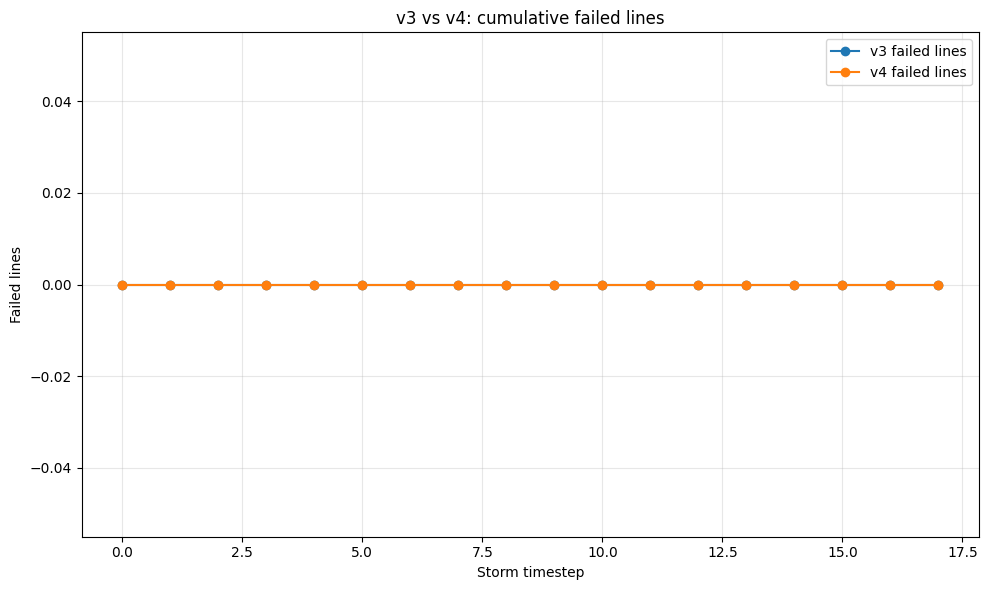

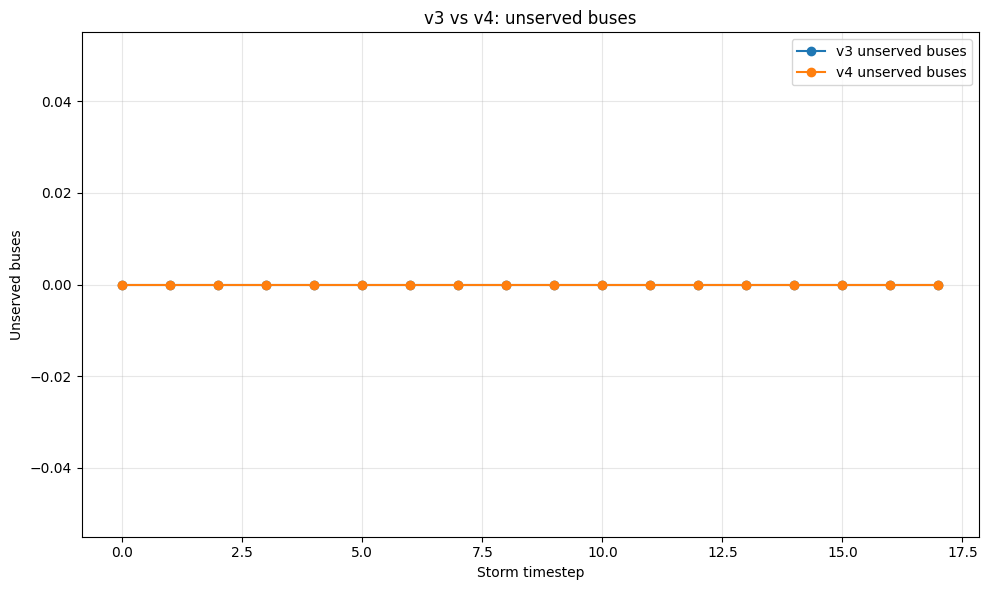

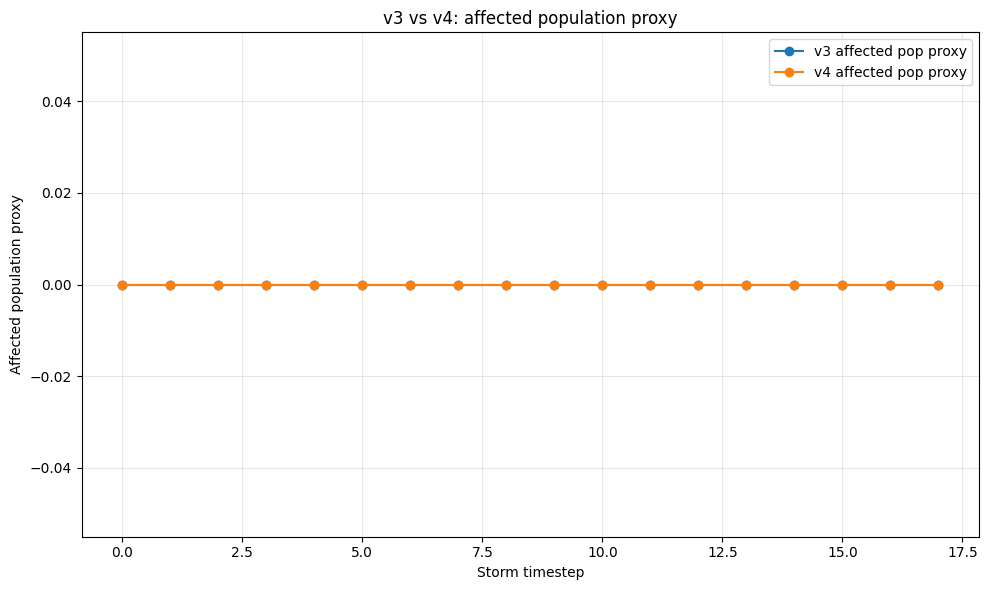

In [103]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["n_failed_lines_cumulative"], marker="o", label="v3 failed lines")
ax.plot(ts_demo_v4["t"], ts_demo_v4["n_failed_lines_cumulative"], marker="o", label="v4 failed lines")
ax.set_title("v3 vs v4: cumulative failed lines")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Failed lines")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["n_unserved_buses"], marker="o", label="v3 unserved buses")
ax.plot(ts_demo_v4["t"], ts_demo_v4["n_unserved_buses"], marker="o", label="v4 unserved buses")
ax.set_title("v3 vs v4: unserved buses")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Unserved buses")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["affected_population_proxy"], marker="o", label="v3 affected pop proxy")
ax.plot(ts_demo_v4["t"], ts_demo_v4["affected_population_proxy"], marker="o", label="v4 affected pop proxy")
ax.set_title("v3 vs v4: affected population proxy")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Test one storm with the new population logic**

In [118]:
storm_id_demo_v4b = ph_points["storm_id"].iloc[0]
storm_year_demo_v4b = int(
    ph_points.loc[ph_points["storm_id"] == storm_id_demo_v4b, "year"].iloc[0]
)

gen_buses_demo_v4b = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=storm_year_demo_v4b,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_demo_v4b, steps_demo_v4b = simulate_grid_impact_timeseries_v4b(
    storm_id=storm_id_demo_v4b,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_buses=gen_buses_demo_v4b,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
)

display(ts_demo_v4b.head())
display(ts_demo_v4b.tail())

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0.0,0.0,0.0,1,0.013822
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0.0,0.0,0.0,1,0.033556
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0.0,0.0,0.0,1,0.146453
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0.0,0.0,0.0,1,0.146765
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0.0,0.0,0.0,1,0.146765


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0.0,0.0,0.0,1,0.146765
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0.0,0.0,0.0,1,0.146765
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0.0,0.0,0.0,1,0.146765
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0.0,0.0,0.0,1,0.146765
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0.0,0.0,0.0,1,0.146765


**Compare v4 old population vs v4b nearest-bus population**

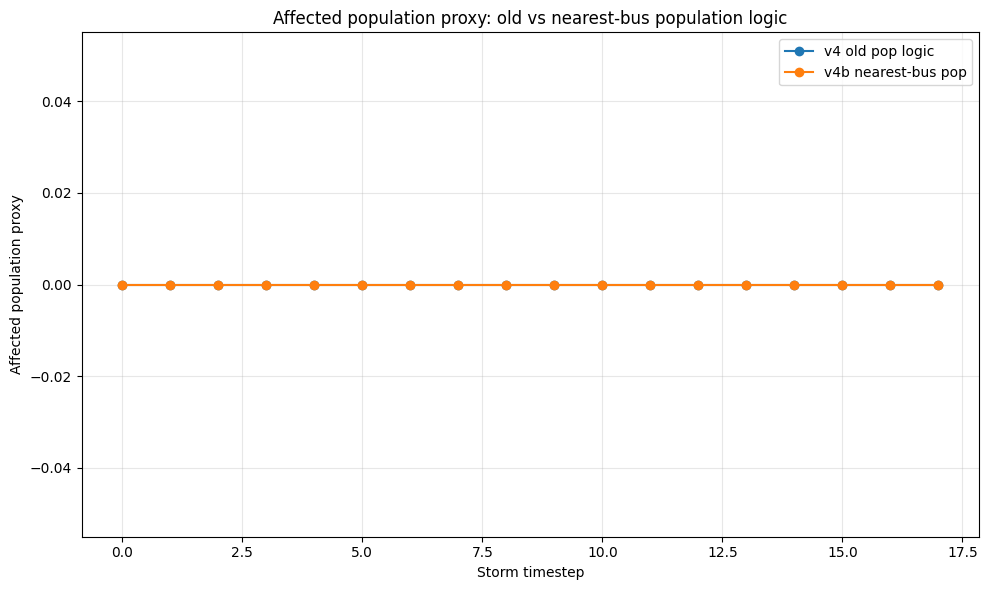

In [119]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v4["t"], ts_demo_v4["affected_population_proxy"], marker="o", label="v4 old pop logic")
ax.plot(ts_demo_v4b["t"], ts_demo_v4b["affected_population_proxy"], marker="o", label="v4b nearest-bus pop")
ax.set_title("Affected population proxy: old vs nearest-bus population logic")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [120]:
top_storm_id_v4b = rank_df_v4.iloc[0]["storm_id"]
top_storm_year_v4b = int(rank_df_v4.iloc[0]["year"])

print("Top storm for v4b test:", top_storm_id_v4b, rank_df_v4.iloc[0]["storm_name"], top_storm_year_v4b)

gen_buses_top_v4b = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=top_storm_year_v4b,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_top_v4_oldpop, steps_top_v4_oldpop = simulate_grid_impact_timeseries_v4(
    storm_id=top_storm_id_v4b,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses,
    G_base=G_base,
    gen_buses=gen_buses_top_v4b,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
)

ts_top_v4b_newpop, steps_top_v4b_newpop = simulate_grid_impact_timeseries_v4b(
    storm_id=top_storm_id_v4b,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_buses=gen_buses_top_v4b,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
)

display(ts_top_v4_oldpop.head())
display(ts_top_v4b_newpop.head())
display(ts_top_v4_oldpop.tail())
display(ts_top_v4b_newpop.tail())

Top storm for v4b test: WP182006 XANGSANE 2006


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP182006,XANGSANE,2006,0,1,0,0.0,0,0.0,0.0,0.0,1,0.000000
1,WP182006,XANGSANE,2006,1,2,0,0.0,0,0.0,0.0,0.0,1,0.000000
2,WP182006,XANGSANE,2006,2,3,0,0.0,0,0.0,0.0,0.0,1,0.000000
3,WP182006,XANGSANE,2006,3,4,0,0.0,0,0.0,0.0,0.0,1,0.031858
4,WP182006,XANGSANE,2006,4,5,0,0.0,0,0.0,0.0,0.0,1,0.061851


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP182006,XANGSANE,2006,0,1,0,0.0,0,0.0,0.0,0.0,1,0.000000
1,WP182006,XANGSANE,2006,1,2,0,0.0,0,0.0,0.0,0.0,1,0.000000
2,WP182006,XANGSANE,2006,2,3,0,0.0,0,0.0,0.0,0.0,1,0.000000
3,WP182006,XANGSANE,2006,3,4,0,0.0,0,0.0,0.0,0.0,1,0.031858
4,WP182006,XANGSANE,2006,4,5,0,0.0,0,0.0,0.0,0.0,1,0.061851


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
9,WP182006,XANGSANE,2006,9,10,19,0.080508,4,0.020833,2.157217e+07,0.015964,16,0.734573
10,WP182006,XANGSANE,2006,10,11,41,0.173729,9,0.046875,9.775005e+07,0.072336,29,0.734573
11,WP182006,XANGSANE,2006,11,12,41,0.173729,9,0.046875,9.775005e+07,0.072336,29,0.734573
12,WP182006,XANGSANE,2006,12,13,41,0.173729,9,0.046875,9.775005e+07,0.072336,29,0.734573
13,WP182006,XANGSANE,2006,13,14,41,0.173729,9,0.046875,9.775005e+07,0.072336,29,0.734573


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
9,WP182006,XANGSANE,2006,9,10,19,0.080508,4,0.020833,3.666347e+06,0.023722,16,0.734573
10,WP182006,XANGSANE,2006,10,11,41,0.173729,9,0.046875,6.154359e+06,0.039820,29,0.734573
11,WP182006,XANGSANE,2006,11,12,41,0.173729,9,0.046875,6.154359e+06,0.039820,29,0.734573
12,WP182006,XANGSANE,2006,12,13,41,0.173729,9,0.046875,6.154359e+06,0.039820,29,0.734573
13,WP182006,XANGSANE,2006,13,14,41,0.173729,9,0.046875,6.154359e+06,0.039820,29,0.734573


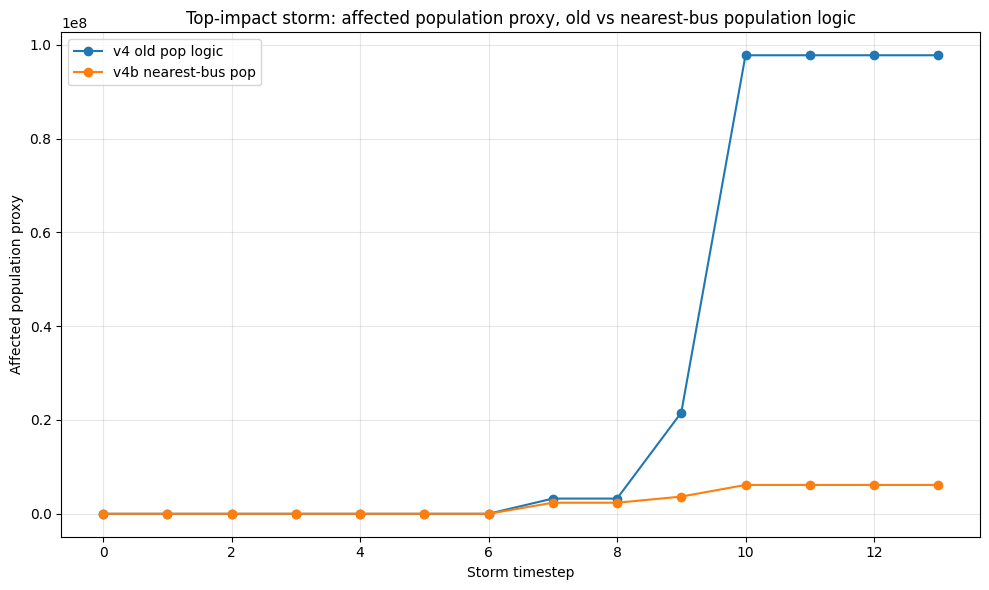

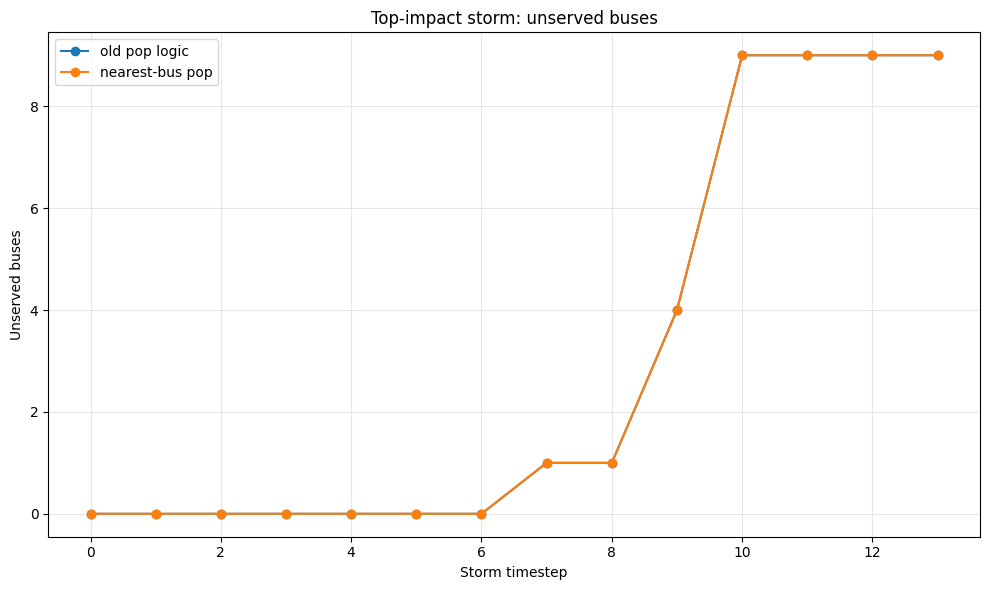

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ts_top_v4_oldpop["t"],
    ts_top_v4_oldpop["affected_population_proxy"],
    marker="o",
    label="v4 old pop logic",
)
ax.plot(
    ts_top_v4b_newpop["t"],
    ts_top_v4b_newpop["affected_population_proxy"],
    marker="o",
    label="v4b nearest-bus pop",
)
ax.set_title("Top-impact storm: affected population proxy, old vs nearest-bus population logic")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ts_top_v4_oldpop["t"],
    ts_top_v4_oldpop["n_unserved_buses"],
    marker="o",
    label="old pop logic",
)
ax.plot(
    ts_top_v4b_newpop["t"],
    ts_top_v4b_newpop["n_unserved_buses"],
    marker="o",
    label="nearest-bus pop",
)
ax.set_title("Top-impact storm: unserved buses")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Unserved buses")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [122]:
print("Old total assigned population:", buses["bus_pop_local"].sum())
print("New total assigned population:", buses_nb["bus_pop_local_nb"].sum())
print("True population total:", pop_ph["pop_value"].sum())

print()
print("Top storm old-pop peak affected:", ts_top_v4_oldpop["affected_population_proxy"].max())
print("Top storm new-pop peak affected:", ts_top_v4b_newpop["affected_population_proxy"].max())
print("Top storm peak unserved buses:", ts_top_v4b_newpop["n_unserved_buses"].max())

Old total assigned population: 1351340186.1247852
New total assigned population: 154555312.94631407
True population total: 154555312.94631407

Top storm old-pop peak affected: 97750052.97245324
Top storm new-pop peak affected: 6154359.041497707
Top storm peak unserved buses: 9


**Run all storms with v4b**

In [123]:
storm_summaries_v4b = []
storm_ts_store_v4b = {}

for _, meta in storm_meta.iterrows():
    storm_id = meta["storm_id"]
    storm_year = int(meta["year"])

    try:
        gen_buses_y = get_generator_buses_for_storm_year(
            generators=generators,
            graph_nodes=G_base.nodes(),
            storm_year=storm_year,
            use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
            year_col=GENERATOR_YEAR_COLUMN,
        )

        ts_df_v4b, _ = simulate_grid_impact_timeseries_v4b(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_buses=gen_buses_y,
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
        )

        storm_ts_store_v4b[storm_id] = ts_df_v4b.copy()

        summary_v4b = summarize_storm_timeseries(ts_df_v4b)
        summary_v4b["n_generator_buses_considered"] = len(gen_buses_y)
        storm_summaries_v4b.append(summary_v4b)

    except Exception as exc:
        print(f"Skipping {storm_id}: {exc}")

storm_rank_v4b = pd.DataFrame(storm_summaries_v4b)

if storm_rank_v4b.empty:
    raise ValueError("No storm summaries were produced for v4b.")

storm_rank_v4b = storm_rank_v4b.sort_values(
    ["peak_affected_population_proxy", "peak_n_failed_lines_cumulative", "peak_n_unserved_buses"],
    ascending=[False, False, False],
).reset_index(drop=True)

storm_rank_v4b["rank"] = storm_rank_v4b.index + 1

display(storm_rank_v4b.head(25))

,storm_id,storm_name,year,peak_t,peak_affected_population_proxy,peak_affected_population_share_proxy,peak_n_unserved_buses,peak_unserved_bus_share,peak_n_failed_lines_cumulative,peak_failed_line_share_cumulative,final_affected_population_proxy,final_n_unserved_buses,final_n_failed_lines_cumulative,n_timesteps,n_generator_buses_considered,rank
0,WP182006,XANGSANE,2006,10,6.154359e+06,0.039820,9,0.046875,41,0.173729,6.154359e+06,9,41,14,133,1
1,WP092014,RAMMASUN,2014,4,5.813806e+06,0.037616,3,0.015625,11,0.046610,5.813806e+06,3,11,9,133,2
2,WP312013,HAIYAN,2013,2,2.700952e+06,0.017476,4,0.020833,17,0.072034,2.700952e+06,4,17,6,133,3
3,WP282021,RAI,2021,2,2.414525e+06,0.015622,4,0.020833,10,0.042373,2.414525e+06,4,10,9,133,4
4,WP222020,GONI,2020,3,2.358922e+06,0.015263,1,0.005208,9,0.038136,2.358922e+06,1,9,11,133,5
5,WP292019,KAMMURI,2019,4,2.358922e+06,0.015263,1,0.005208,4,0.016949,2.358922e+06,1,4,12,133,6
6,WP182022,NORU,2022,12,3.893850e+05,0.002519,2,0.010417,15,0.063559,3.893850e+05,2,15,20,133,7
7,WP252020,VAMCO,2020,6,3.893850e+05,0.002519,2,0.010417,5,0.021186,3.893850e+05,2,5,11,133,8
8,WP242006,DURIAN,2006,0,0.000000e+00,0.000000,0,0.000000,13,0.055085,0.000000e+00,0,13,13,133,9
9,WP262012,BOPHA,2012,0,0.000000e+00,0.000000,0,0.000000,10,0.042373,0.000000e+00,0,10,21,133,10


**Build the v4b composite impact index**

In [124]:
rank_df_v4b = storm_rank_v4b.copy()

rank_df_v4b["peak_affected_population_proxy_norm"] = minmax_normalize(rank_df_v4b["peak_affected_population_proxy"])
rank_df_v4b["peak_n_failed_lines_norm"] = minmax_normalize(rank_df_v4b["peak_n_failed_lines_cumulative"])
rank_df_v4b["peak_n_unserved_buses_norm"] = minmax_normalize(rank_df_v4b["peak_n_unserved_buses"])

rank_df_v4b["grid_impact_index_v4b"] = (
    0.60 * rank_df_v4b["peak_affected_population_proxy_norm"]
    + 0.25 * rank_df_v4b["peak_n_failed_lines_norm"]
    + 0.15 * rank_df_v4b["peak_n_unserved_buses_norm"]
)

rank_df_v4b = rank_df_v4b.sort_values("grid_impact_index_v4b", ascending=False).reset_index(drop=True)
rank_df_v4b["rank_index"] = rank_df_v4b.index + 1

display(
    rank_df_v4b[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v4b",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

,rank_index,storm_id,storm_name,year,grid_impact_index_v4b,peak_affected_population_proxy,peak_n_failed_lines_cumulative,peak_n_unserved_buses,peak_t
0,1,WP182006,XANGSANE,2006,1.000000,6.154359e+06,41,9,10
1,2,WP092014,RAMMASUN,2014,0.683872,5.813806e+06,11,3,4
2,3,WP312013,HAIYAN,2013,0.433646,2.700952e+06,17,4,2
3,4,WP282021,RAI,2021,0.363039,2.414525e+06,10,4,2
4,5,WP222020,GONI,2020,0.301520,2.358922e+06,9,1,3
5,6,WP292019,KAMMURI,2019,0.271033,2.358922e+06,4,1,4
6,7,WP182022,NORU,2022,0.162759,3.893850e+05,15,2,12
7,8,WP252020,VAMCO,2020,0.101783,3.893850e+05,5,2,6
8,9,WP242006,DURIAN,2006,0.079268,0.000000e+00,13,0,0
9,10,WP262012,BOPHA,2012,0.060976,0.000000e+00,10,0,0


In [133]:
compare_v4_v4b_clean = compare_v4_v4b[
    (compare_v4_v4b["grid_impact_index_v4"] > 0) |
    (compare_v4_v4b["grid_impact_index_v4b"] > 0)
].copy()

compare_v4_v4b_clean = compare_v4_v4b_clean.sort_values(
    ["abs_rank_shift", "rank_v4b"],
    ascending=[False, True],
).reset_index(drop=True)

display(compare_v4_v4b_clean.head(25))
print(compare_v4_v4b_clean.shape)
print(compare_v4_v4b_clean.columns.tolist())

,storm_id,storm_name,year,grid_impact_index_v4,grid_impact_index_v4b,rank_v4,rank_v4b,rank_shift,abs_rank_shift
0,WP182022,NORU,2022,0.412180,0.162759,2.0,7.0,-5.0,5.0
1,WP252020,VAMCO,2020,0.351204,0.101783,3.0,8.0,-5.0,5.0
2,WP092014,RAMMASUN,2014,0.156278,0.683872,6.0,2.0,4.0,4.0
3,WP292019,KAMMURI,2019,0.060967,0.271033,10.0,6.0,4.0,4.0
4,WP312013,HAIYAN,2013,0.226380,0.433646,5.0,3.0,2.0,2.0
5,WP222020,GONI,2020,0.091455,0.301520,7.0,5.0,2.0,2.0
6,WP242006,DURIAN,2006,0.079268,0.079268,8.0,9.0,-1.0,1.0
7,WP262012,BOPHA,2012,0.060976,0.060976,9.0,10.0,-1.0,1.0
8,WP182006,XANGSANE,2006,1.000000,1.000000,1.0,1.0,0.0,0.0
9,WP282021,RAI,2021,0.262604,0.363039,4.0,4.0,0.0,0.0


(19, 9)
['storm_id', 'storm_name', 'year', 'grid_impact_index_v4', 'grid_impact_index_v4b', 'rank_v4', 'rank_v4b', 'rank_shift', 'abs_rank_shift']


**Compare v4 vs v4b directly**

In [134]:
compare_v4_v4b = rank_df_v4[
    ["storm_id", "storm_name", "year", "grid_impact_index_v4"]
].merge(
    rank_df_v4b[["storm_id", "grid_impact_index_v4b"]],
    on="storm_id",
    how="inner",
)

compare_v4_v4b["rank_v4"] = compare_v4_v4b["grid_impact_index_v4"].rank(ascending=False, method="min")
compare_v4_v4b["rank_v4b"] = compare_v4_v4b["grid_impact_index_v4b"].rank(ascending=False, method="min")
compare_v4_v4b["rank_shift"] = compare_v4_v4b["rank_v4"] - compare_v4_v4b["rank_v4b"]
compare_v4_v4b["abs_rank_shift"] = compare_v4_v4b["rank_shift"].abs()

compare_v4_v4b = compare_v4_v4b.sort_values(
    ["abs_rank_shift", "rank_v4b"],
    ascending=[False, True]
).reset_index(drop=True)

display(compare_v4_v4b.head(30))

,storm_id,storm_name,year,grid_impact_index_v4,grid_impact_index_v4b,rank_v4,rank_v4b,rank_shift,abs_rank_shift
0,WP182022,NORU,2022,0.412180,0.162759,2.0,7.0,-5.0,5.0
1,WP252020,VAMCO,2020,0.351204,0.101783,3.0,8.0,-5.0,5.0
2,WP092014,RAMMASUN,2014,0.156278,0.683872,6.0,2.0,4.0,4.0
3,WP292019,KAMMURI,2019,0.060967,0.271033,10.0,6.0,4.0,4.0
4,WP312013,HAIYAN,2013,0.226380,0.433646,5.0,3.0,2.0,2.0
5,WP222020,GONI,2020,0.091455,0.301520,7.0,5.0,2.0,2.0
6,WP242006,DURIAN,2006,0.079268,0.079268,8.0,9.0,-1.0,1.0
7,WP262012,BOPHA,2012,0.060976,0.060976,9.0,10.0,-1.0,1.0
8,WP182006,XANGSANE,2006,1.000000,1.000000,1.0,1.0,0.0,0.0
9,WP282021,RAI,2021,0.262604,0.363039,4.0,4.0,0.0,0.0


**Filter the comparison to storms with actual impact**

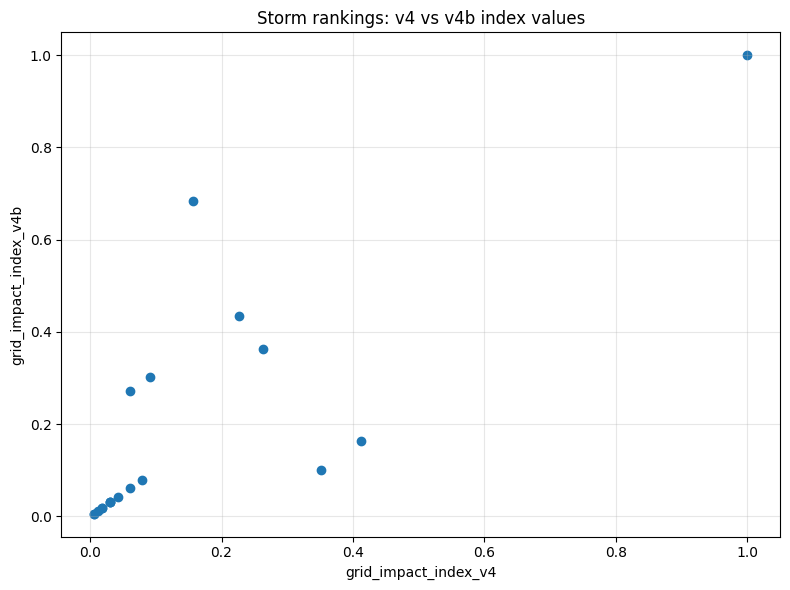

In [135]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    compare_v4_v4b_clean["grid_impact_index_v4"],
    compare_v4_v4b_clean["grid_impact_index_v4b"],
)
ax.set_xlabel("grid_impact_index_v4")
ax.set_ylabel("grid_impact_index_v4b")
ax.set_title("Storm rankings: v4 vs v4b index values")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Canonical model choice

From this point onward, the preferred specification is **v4b**:
- stylized wind-field hazard (`v4`)
- unique nearest-bus population assignment (`v4b`)

Older versions (`v3`, `v4`) are retained only for benchmarking and comparison.

**Run all storms with v4**

In [104]:
storm_summaries_v4 = []
storm_ts_store_v4 = {}

for _, meta in storm_meta.iterrows():
    storm_id = meta["storm_id"]
    storm_year = int(meta["year"])

    try:
        gen_buses_y = get_generator_buses_for_storm_year(
            generators=generators,
            graph_nodes=G_base.nodes(),
            storm_year=storm_year,
            use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
            year_col=GENERATOR_YEAR_COLUMN,
        )

        ts_df_v4, _ = simulate_grid_impact_timeseries_v4(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses,
            G_base=G_base,
            gen_buses=gen_buses_y,
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        )

        storm_ts_store_v4[storm_id] = ts_df_v4.copy()

        summary_v4 = summarize_storm_timeseries(ts_df_v4)
        summary_v4["n_generator_buses_considered"] = len(gen_buses_y)
        storm_summaries_v4.append(summary_v4)

    except Exception as exc:
        print(f"Skipping {storm_id}: {exc}")

storm_rank_v4 = pd.DataFrame(storm_summaries_v4)

if storm_rank_v4.empty:
    raise ValueError("No storm summaries were produced for v4.")

storm_rank_v4 = storm_rank_v4.sort_values(
    ["peak_affected_population_proxy", "peak_n_failed_lines_cumulative", "peak_n_unserved_buses"],
    ascending=[False, False, False],
).reset_index(drop=True)

storm_rank_v4["rank"] = storm_rank_v4.index + 1

display(storm_rank_v4.head(25))

,storm_id,storm_name,year,peak_t,peak_affected_population_proxy,peak_affected_population_share_proxy,peak_n_unserved_buses,peak_unserved_bus_share,peak_n_failed_lines_cumulative,peak_failed_line_share_cumulative,final_affected_population_proxy,final_n_unserved_buses,final_n_failed_lines_cumulative,n_timesteps,n_generator_buses_considered,rank
0,WP182006,XANGSANE,2006,10,9.775005e+07,0.072336,9,0.046875,41,0.173729,9.775005e+07,9,41,14,133,1
1,WP182022,NORU,2022,12,4.681956e+07,0.034647,2,0.010417,15,0.063559,4.681956e+07,2,15,20,133,2
2,WP252020,VAMCO,2020,6,4.681956e+07,0.034647,2,0.010417,5,0.021186,4.681956e+07,2,5,11,133,3
3,WP282021,RAI,2021,2,2.198753e+07,0.016271,4,0.020833,10,0.042373,2.198753e+07,4,10,9,133,4
4,WP312013,HAIYAN,2013,2,9.132244e+06,0.006758,4,0.020833,17,0.072034,9.132244e+06,4,17,6,133,5
5,WP092014,RAMMASUN,2014,4,6.387112e+06,0.004727,3,0.015625,11,0.046610,6.387112e+06,3,11,9,133,6
6,WP222020,GONI,2020,3,3.243706e+06,0.002400,1,0.005208,9,0.038136,3.243706e+06,1,9,11,133,7
7,WP292019,KAMMURI,2019,4,3.243706e+06,0.002400,1,0.005208,4,0.016949,3.243706e+06,1,4,12,133,8
8,WP242006,DURIAN,2006,0,0.000000e+00,0.000000,0,0.000000,13,0.055085,0.000000e+00,0,13,13,133,9
9,WP262012,BOPHA,2012,0,0.000000e+00,0.000000,0,0.000000,10,0.042373,0.000000e+00,0,10,21,133,10


**Build v4 composite impact index**

In [105]:
rank_df_v4 = storm_rank_v4.copy()

rank_df_v4["peak_affected_population_proxy_norm"] = minmax_normalize(rank_df_v4["peak_affected_population_proxy"])
rank_df_v4["peak_n_failed_lines_norm"] = minmax_normalize(rank_df_v4["peak_n_failed_lines_cumulative"])
rank_df_v4["peak_n_unserved_buses_norm"] = minmax_normalize(rank_df_v4["peak_n_unserved_buses"])

rank_df_v4["grid_impact_index_v4"] = (
    0.60 * rank_df_v4["peak_affected_population_proxy_norm"]
    + 0.25 * rank_df_v4["peak_n_failed_lines_norm"]
    + 0.15 * rank_df_v4["peak_n_unserved_buses_norm"]
)

rank_df_v4 = rank_df_v4.sort_values("grid_impact_index_v4", ascending=False).reset_index(drop=True)
rank_df_v4["rank_index"] = rank_df_v4.index + 1

display(
    rank_df_v4[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v4",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

,rank_index,storm_id,storm_name,year,grid_impact_index_v4,peak_affected_population_proxy,peak_n_failed_lines_cumulative,peak_n_unserved_buses,peak_t
0,1,WP182006,XANGSANE,2006,1.000000,9.775005e+07,41,9,10
1,2,WP182022,NORU,2022,0.412180,4.681956e+07,15,2,12
2,3,WP252020,VAMCO,2020,0.351204,4.681956e+07,5,2,6
3,4,WP282021,RAI,2021,0.262604,2.198753e+07,10,4,2
4,5,WP312013,HAIYAN,2013,0.226380,9.132244e+06,17,4,2
5,6,WP092014,RAMMASUN,2014,0.156278,6.387112e+06,11,3,4
6,7,WP222020,GONI,2020,0.091455,3.243706e+06,9,1,3
7,8,WP242006,DURIAN,2006,0.079268,0.000000e+00,13,0,0
8,9,WP262012,BOPHA,2012,0.060976,0.000000e+00,10,0,0
9,10,WP292019,KAMMURI,2019,0.060967,3.243706e+06,4,1,4


**Compare v3 and v4 rankings**

In [106]:
compare_rank = rank_df_v3[
    ["storm_id", "storm_name", "year", "grid_impact_index_v3"]
].merge(
    rank_df_v4[["storm_id", "grid_impact_index_v4"]],
    on="storm_id",
    how="outer",
)

compare_rank["rank_v3"] = compare_rank["grid_impact_index_v3"].rank(ascending=False, method="min")
compare_rank["rank_v4"] = compare_rank["grid_impact_index_v4"].rank(ascending=False, method="min")
compare_rank["rank_shift"] = compare_rank["rank_v3"] - compare_rank["rank_v4"]

compare_rank["abs_rank_shift"] = compare_rank["rank_shift"].abs()

compare_rank = compare_rank.sort_values(
    ["abs_rank_shift", "grid_impact_index_v4"],
    ascending=[False, False]
).reset_index(drop=True)

display(compare_rank.head(30))

,storm_id,storm_name,year,grid_impact_index_v3,grid_impact_index_v4,rank_v3,rank_v4,rank_shift,abs_rank_shift
0,WP012001,UNNAMED,2001,0.0,0.0,7.0,20.0,-13.0,13.0
1,WP012002,TAPAH,2002,0.0,0.0,7.0,20.0,-13.0,13.0
2,WP012008,UNNAMED,2008,0.0,0.0,7.0,20.0,-13.0,13.0
3,WP012009,KUJIRA,2009,0.0,0.0,7.0,20.0,-13.0,13.0
4,WP012012,UNNAMED,2012,0.0,0.0,7.0,20.0,-13.0,13.0
5,WP012013,SONAMU,2013,0.0,0.0,7.0,20.0,-13.0,13.0
6,WP012014,LINGLING,2014,0.0,0.0,7.0,20.0,-13.0,13.0
7,WP012015,MEKKHALA,2015,0.0,0.0,7.0,20.0,-13.0,13.0
8,WP012017,UNNAMED,2017,0.0,0.0,7.0,20.0,-13.0,13.0
9,WP012018,BOLAVEN,2017,0.0,0.0,7.0,20.0,-13.0,13.0


In [110]:
rank_compare_clean = rank_df_v3.merge(
    rank_df_v4,
    on="storm_id",
    suffixes=("_v3", "_v4"),
)

rank_compare_clean = rank_compare_clean[
    (rank_compare_clean["grid_impact_index_v3"] > 0) |
    (rank_compare_clean["grid_impact_index_v4"] > 0)
].copy()

rank_compare_clean["rank_v3"] = rank_compare_clean["grid_impact_index_v3"].rank(ascending=False, method="min")
rank_compare_clean["rank_v4"] = rank_compare_clean["grid_impact_index_v4"].rank(ascending=False, method="min")
rank_compare_clean["rank_shift"] = rank_compare_clean["rank_v3"] - rank_compare_clean["rank_v4"]
rank_compare_clean["abs_rank_shift"] = rank_compare_clean["rank_shift"].abs()

rank_compare_clean = rank_compare_clean.sort_values(
    ["abs_rank_shift", "rank_v4"],
    ascending=[False, True]
).reset_index(drop=True)

display(
    rank_compare_clean[
        [
            "storm_id",
            "storm_name_v3",
            "year_v3",
            "grid_impact_index_v3",
            "grid_impact_index_v4",
            "rank_v3",
            "rank_v4",
            "rank_shift",
            "abs_rank_shift",
        ]
    ].head(25)
)

,storm_id,storm_name_v3,year_v3,grid_impact_index_v3,grid_impact_index_v4,rank_v3,rank_v4,rank_shift,abs_rank_shift
0,WP222011,NALGAE,2011,0.035714,0.012195,5.0,17.0,-12.0,12.0
1,WP072008,FENGSHEN,2008,0.000000,0.006098,7.0,18.0,-11.0,11.0
2,WP302019,PHANFONE,2019,0.000000,0.006098,7.0,18.0,-11.0,11.0
3,WP152010,MEGI,2010,0.000000,0.018293,7.0,15.0,-8.0,8.0
4,WP242015,KOPPU,2015,0.000000,0.018293,7.0,15.0,-8.0,8.0
5,WP222020,GONI,2020,0.142857,0.091455,2.0,7.0,-5.0,5.0
6,WP112013,UTOR,2013,0.000000,0.030488,7.0,12.0,-5.0,5.0
7,WP302016,NOCK-TEN,2016,0.000000,0.030488,7.0,12.0,-5.0,5.0
8,WP262018,MANGKHUT,2018,0.000000,0.030488,7.0,12.0,-5.0,5.0
9,WP252020,VAMCO,2020,0.000000,0.351204,7.0,3.0,4.0,4.0


**Quick visual comparison of top storms**

In [107]:
top_v3 = set(rank_df_v3.head(15)["storm_id"])
top_v4 = set(rank_df_v4.head(15)["storm_id"])

comparison_flags = rank_df_v4[["storm_id", "storm_name", "year", "grid_impact_index_v4"]].copy()
comparison_flags["in_top15_v3"] = comparison_flags["storm_id"].isin(top_v3)
comparison_flags["in_top15_v4"] = comparison_flags["storm_id"].isin(top_v4)

display(comparison_flags.head(25))
print("Common storms in top 15:", len(top_v3 & top_v4))
print("Only in v3 top 15:", len(top_v3 - top_v4))
print("Only in v4 top 15:", len(top_v4 - top_v3))

,storm_id,storm_name,year,grid_impact_index_v4,in_top15_v3,in_top15_v4
0,WP182006,XANGSANE,2006,1.000000,True,True
1,WP182022,NORU,2022,0.412180,True,True
2,WP252020,VAMCO,2020,0.351204,False,True
3,WP282021,RAI,2021,0.262604,False,True
4,WP312013,HAIYAN,2013,0.226380,True,True
5,WP092014,RAMMASUN,2014,0.156278,False,True
6,WP222020,GONI,2020,0.091455,True,True
7,WP242006,DURIAN,2006,0.079268,True,True
8,WP262012,BOPHA,2012,0.060976,False,True
9,WP292019,KAMMURI,2019,0.060967,False,True


Common storms in top 15: 5
Only in v3 top 15: 10
Only in v4 top 15: 10


**Add a “v3 vs v4 shift” inspection table**

In [108]:
rank_compare_clean = rank_df_v3[
    ["storm_id", "storm_name", "year", "grid_impact_index_v3"]
].merge(
    rank_df_v4[["storm_id", "grid_impact_index_v4"]],
    on="storm_id",
    how="inner",
)

rank_compare_clean["rank_v3"] = rank_compare_clean["grid_impact_index_v3"].rank(ascending=False, method="min")
rank_compare_clean["rank_v4"] = rank_compare_clean["grid_impact_index_v4"].rank(ascending=False, method="min")
rank_compare_clean["rank_shift"] = rank_compare_clean["rank_v3"] - rank_compare_clean["rank_v4"]
rank_compare_clean["abs_rank_shift"] = rank_compare_clean["rank_shift"].abs()

rank_compare_clean = rank_compare_clean.sort_values(
    ["abs_rank_shift", "rank_v4"],
    ascending=[False, True]
).reset_index(drop=True)

display(rank_compare_clean.head(20))

,storm_id,storm_name,year,grid_impact_index_v3,grid_impact_index_v4,rank_v3,rank_v4,rank_shift,abs_rank_shift
0,WP022000,LONGWANG,2000,0.0,0.0,7.0,20.0,-13.0,13.0
1,WP032000,UNNAMED,2000,0.0,0.0,7.0,20.0,-13.0,13.0
2,WP042000,UNNAMED,2000,0.0,0.0,7.0,20.0,-13.0,13.0
3,WP062000,KAI-TAK,2000,0.0,0.0,7.0,20.0,-13.0,13.0
4,WP072000,UNNAMED,2000,0.0,0.0,7.0,20.0,-13.0,13.0
5,WP102000,BOLAVEN,2000,0.0,0.0,7.0,20.0,-13.0,13.0
6,WP182000,BILIS,2000,0.0,0.0,7.0,20.0,-13.0,13.0
7,WP192000,KAEMI,2000,0.0,0.0,7.0,20.0,-13.0,13.0
8,WP212000,MARIA,2000,0.0,0.0,7.0,20.0,-13.0,13.0
9,WP232000,WUKONG,2000,0.0,0.0,7.0,20.0,-13.0,13.0


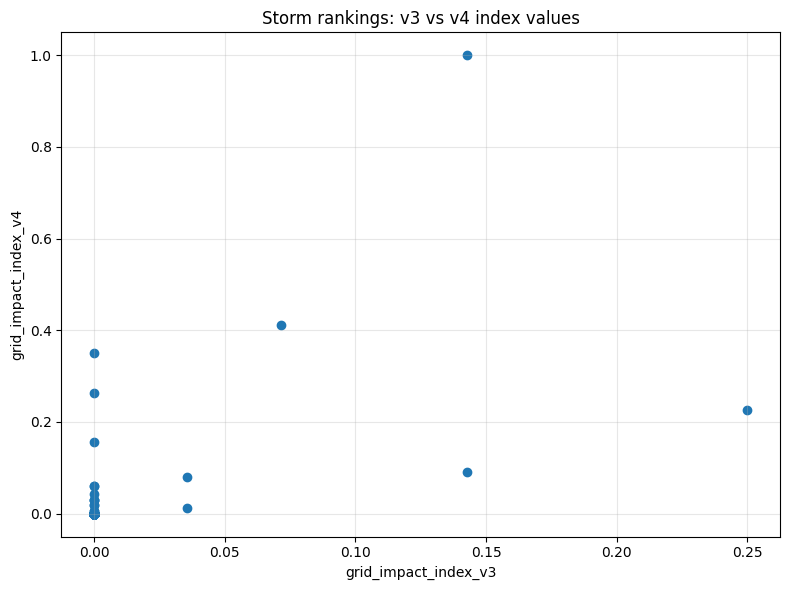

In [109]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rank_compare_clean["grid_impact_index_v3"], rank_compare_clean["grid_impact_index_v4"])
ax.set_xlabel("grid_impact_index_v3")
ax.set_ylabel("grid_impact_index_v4")
ax.set_title("Storm rankings: v3 vs v4 index values")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Plot the storm time trajectory**

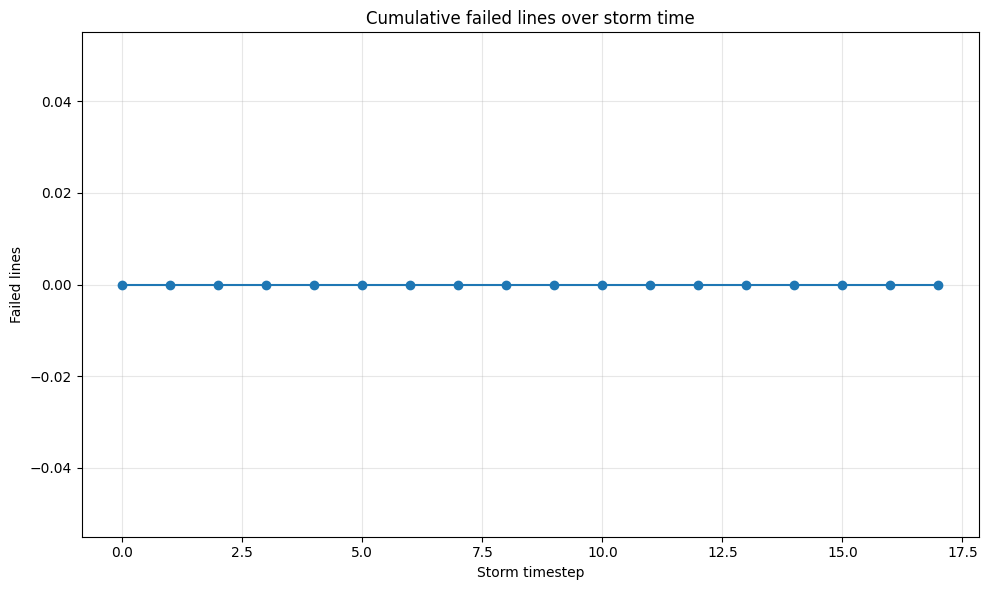

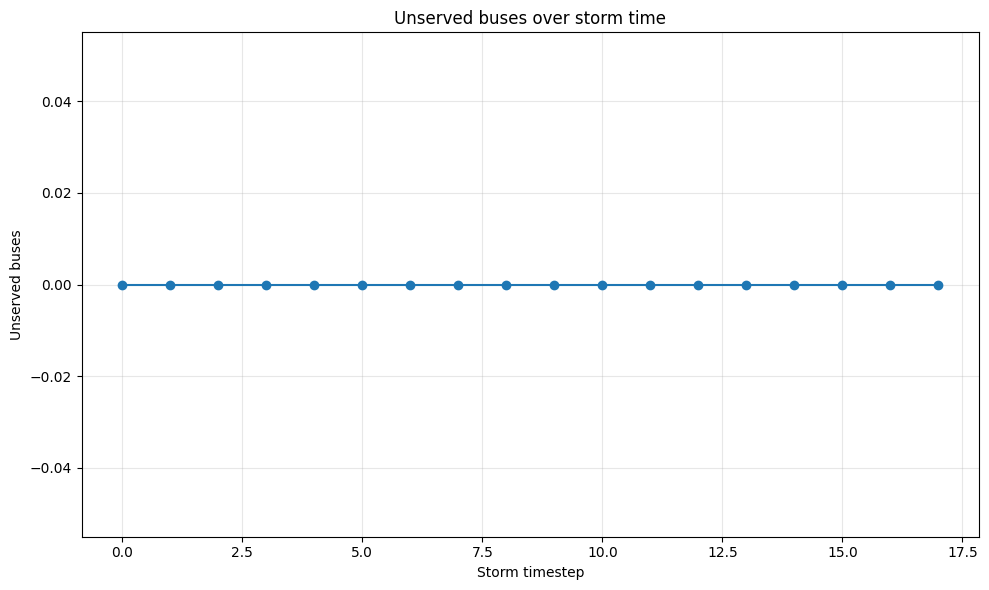

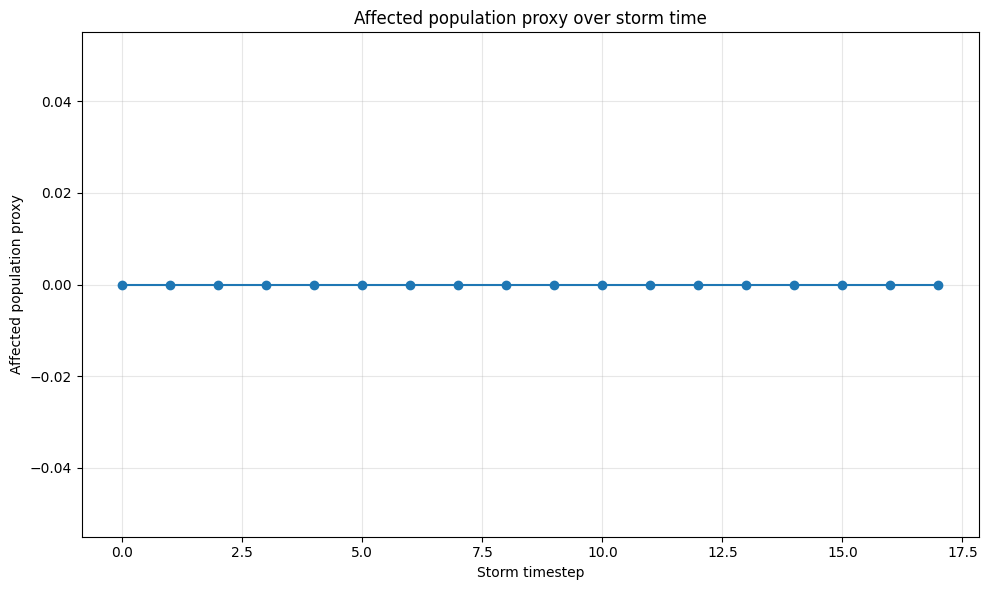

In [87]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["n_failed_lines_cumulative"], marker="o")
ax.set_title("Cumulative failed lines over storm time")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Failed lines")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["n_unserved_buses"], marker="o")
ax.set_title("Unserved buses over storm time")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Unserved buses")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v3["t"], ts_demo_v3["affected_population_proxy"], marker="o")
ax.set_title("Affected population proxy over storm time")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Static snapshot helper for any timestep**

In [88]:
def plot_storm_step(step_output, bounds=PH_BOUNDS):
    lf = step_output["lf"]
    bus_state = step_output["bus_state"]
    storm_track = step_output["storm_points_up_to_t"]
    rec = step_output["record"]

    fig, ax = plt.subplots(figsize=(9, 9))

    for _, row in lf.loc[~lf["failed_cumulative"]].iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            linewidth=0.5,
            alpha=0.12,
        )

    for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            linewidth=1.5,
            alpha=0.9,
        )

    served = bus_state.loc[bus_state["served"]]
    unserved = bus_state.loc[bus_state["unserved"]]

    ax.scatter(served["lon"], served["lat"], s=18, label="Served buses")
    ax.scatter(unserved["lon"], unserved["lat"], s=35, marker="x", label="Unserved buses")

    ax.plot(
        storm_track["lon"],
        storm_track["lat"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Storm path so far",
    )

    latest = storm_track.iloc[-1]
    ax.scatter([latest["lon"]], [latest["lat"]], s=80, marker="o", label="Current storm position")

    ax.set_xlim(bounds["lon_min"], bounds["lon_max"])
    ax.set_ylim(bounds["lat_min"], bounds["lat_max"])
    ax.set_title(
        f"{rec['storm_name']} ({rec['year']}) [{rec['storm_id']}] | "
        f"t={rec['t']} | failed={rec['n_failed_lines_cumulative']} | "
        f"unserved={rec['n_unserved_buses']}"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

**Inspect a few timesteps manually**

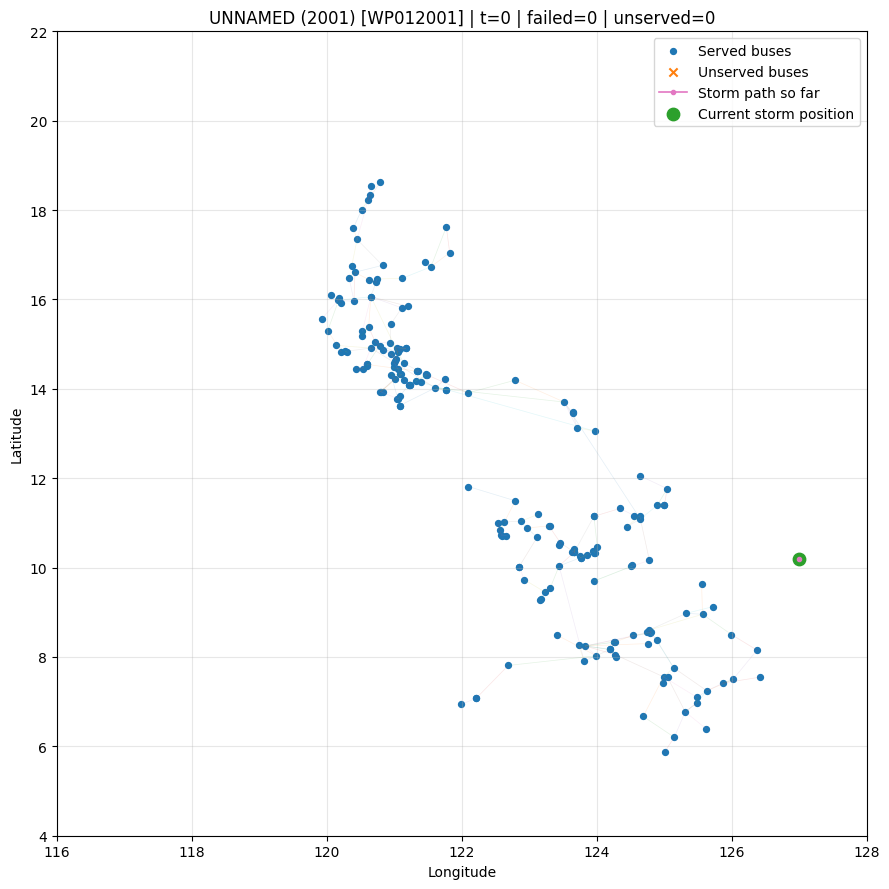

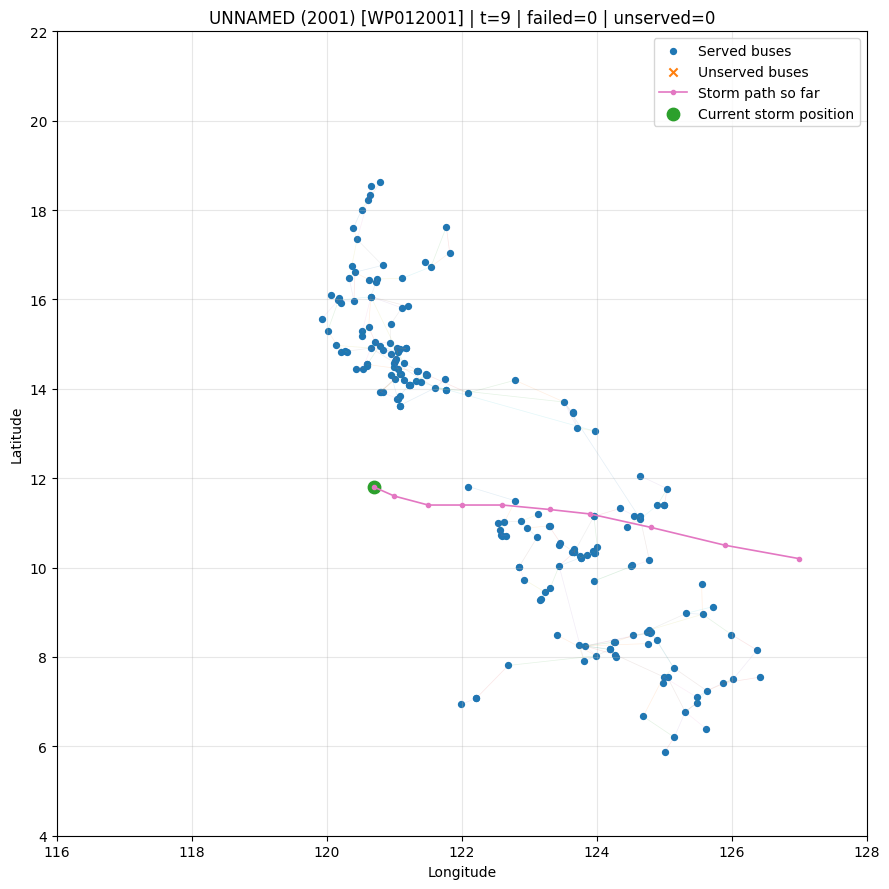

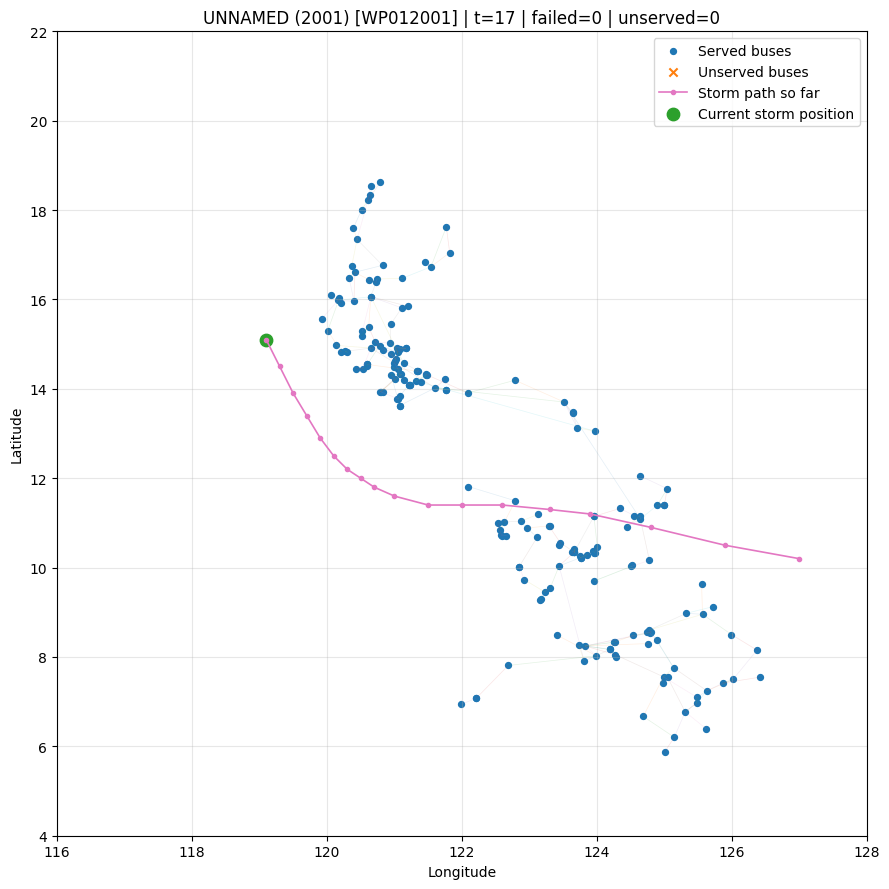

In [89]:
plot_storm_step(steps_demo_v3[0])

mid_idx = len(steps_demo_v3) // 2
plot_storm_step(steps_demo_v3[mid_idx])

plot_storm_step(steps_demo_v3[-1])

**Animation helper**

In [90]:
def animate_storm_impact(
    step_outputs,
    out_gif_path=None,
    bounds=PH_BOUNDS,
    interval=600,
):
    fig, ax = plt.subplots(figsize=(9, 9))

    def update(frame_idx):
        ax.clear()

        step_output = step_outputs[frame_idx]
        lf = step_output["lf"]
        bus_state = step_output["bus_state"]
        storm_track = step_output["storm_points_up_to_t"]
        rec = step_output["record"]

        for _, row in lf.loc[~lf["failed_cumulative"]].iterrows():
            ax.plot(
                [row["lon0"], row["lon1"]],
                [row["lat0"], row["lat1"]],
                linewidth=0.5,
                alpha=0.12,
            )

        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            ax.plot(
                [row["lon0"], row["lon1"]],
                [row["lat0"], row["lat1"]],
                linewidth=1.7,
                alpha=0.95,
            )

        served = bus_state.loc[bus_state["served"]]
        unserved = bus_state.loc[bus_state["unserved"]]

        ax.scatter(served["lon"], served["lat"], s=18)
        ax.scatter(unserved["lon"], unserved["lat"], s=35, marker="x")

        ax.plot(
            storm_track["lon"],
            storm_track["lat"],
            marker="o",
            markersize=3,
            linewidth=1.2,
        )

        latest = storm_track.iloc[-1]
        ax.scatter([latest["lon"]], [latest["lat"]], s=80, marker="o")

        ax.set_xlim(bounds["lon_min"], bounds["lon_max"])
        ax.set_ylim(bounds["lat_min"], bounds["lat_max"])
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        ax.set_title(
            f"{rec['storm_name']} ({rec['year']}) [{rec['storm_id']}] | "
            f"t={rec['t']} | failed lines={rec['n_failed_lines_cumulative']} | "
            f"unserved buses={rec['n_unserved_buses']} | "
            f"affected pop proxy={rec['affected_population_proxy']:.0f}"
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=len(step_outputs),
        interval=interval,
        repeat=False,
    )

    plt.close(fig)

    if out_gif_path is not None:
        anim.save(out_gif_path, writer=PillowWriter(fps=max(1, int(1000 / interval))))
        print("Saved animation to:", out_gif_path)

    return anim

**Run and display the animation**

In [91]:
demo_gif_v3 = OUTPUT_DIR / f"storm_animation_v3_{storm_id_demo}.gif"

anim_v3 = animate_storm_impact(
    step_outputs=steps_demo_v3,
    out_gif_path=demo_gif_v3,
    interval=700,
)

HTML(anim_v3.to_jshtml())

Saved animation to: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_v3_WP012001.gif


**Convert each storm to a single event summary**

In [92]:
def summarize_storm_timeseries(ts_df):
    if ts_df.empty:
        raise ValueError("ts_df is empty")

    peak_idx = ts_df["affected_population_proxy"].idxmax()
    peak_row = ts_df.loc[peak_idx].copy()

    out = {
        "storm_id": peak_row["storm_id"],
        "storm_name": peak_row["storm_name"],
        "year": int(peak_row["year"]),
        "peak_t": int(peak_row["t"]),
        "peak_affected_population_proxy": float(ts_df["affected_population_proxy"].max()),
        "peak_affected_population_share_proxy": float(ts_df["affected_population_share_proxy"].max()),
        "peak_n_unserved_buses": int(ts_df["n_unserved_buses"].max()),
        "peak_unserved_bus_share": float(ts_df["unserved_bus_share"].max()),
        "peak_n_failed_lines_cumulative": int(ts_df["n_failed_lines_cumulative"].max()),
        "peak_failed_line_share_cumulative": float(ts_df["failed_line_share_cumulative"].max()),
        "final_affected_population_proxy": float(ts_df.iloc[-1]["affected_population_proxy"]),
        "final_n_unserved_buses": int(ts_df.iloc[-1]["n_unserved_buses"]),
        "final_n_failed_lines_cumulative": int(ts_df.iloc[-1]["n_failed_lines_cumulative"]),
        "n_timesteps": int(len(ts_df)),
    }
    return out

**Run all storms with time dynamics**

In [93]:
storm_meta = (
    ph_points.groupby("storm_id", as_index=False)
    .agg(
        storm_name=("storm_name", "first"),
        year=("year", "first"),
    )
    .sort_values(["year", "storm_id"])
    .reset_index(drop=True)
)

storm_summaries_v3 = []
storm_ts_store_v3 = {}

for _, meta in storm_meta.iterrows():
    storm_id = meta["storm_id"]
    storm_year = int(meta["year"])

    try:
        gen_buses_y = get_generator_buses_for_storm_year(
            generators=generators,
            graph_nodes=G_base.nodes(),
            storm_year=storm_year,
            use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
            year_col=GENERATOR_YEAR_COLUMN,
        )

        ts_df_v3, _ = simulate_grid_impact_timeseries_v3(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses,
            G_base=G_base,
            gen_buses=gen_buses_y,
            decay_km=DECAY_KM,
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
        )

        storm_ts_store_v3[storm_id] = ts_df_v3.copy()

        summary_v3 = summarize_storm_timeseries(ts_df_v3)
        summary_v3["n_generator_buses_considered"] = len(gen_buses_y)
        storm_summaries_v3.append(summary_v3)

    except Exception as exc:
        print(f"Skipping {storm_id}: {exc}")

storm_rank_v3 = pd.DataFrame(storm_summaries_v3)

if storm_rank_v3.empty:
    raise ValueError("No storm summaries were produced.")

storm_rank_v3 = storm_rank_v3.sort_values(
    ["peak_affected_population_proxy", "peak_n_failed_lines_cumulative", "peak_n_unserved_buses"],
    ascending=[False, False, False],
).reset_index(drop=True)

storm_rank_v3["rank"] = storm_rank_v3.index + 1

display(storm_rank_v3.head(25))

,storm_id,storm_name,year,peak_t,peak_affected_population_proxy,peak_affected_population_share_proxy,peak_n_unserved_buses,peak_unserved_bus_share,peak_n_failed_lines_cumulative,peak_failed_line_share_cumulative,final_affected_population_proxy,final_n_unserved_buses,final_n_failed_lines_cumulative,n_timesteps,n_generator_buses_considered,rank
0,WP312013,HAIYAN,2013,0,0.0,0.0,0,0.0,7,0.029661,0.0,0,7,6,133,1
1,WP182006,XANGSANE,2006,0,0.0,0.0,0,0.0,4,0.016949,0.0,0,4,14,133,2
2,WP222020,GONI,2020,0,0.0,0.0,0,0.0,4,0.016949,0.0,0,4,11,133,3
3,WP182022,NORU,2022,0,0.0,0.0,0,0.0,2,0.008475,0.0,0,2,20,133,4
4,WP242006,DURIAN,2006,0,0.0,0.0,0,0.0,1,0.004237,0.0,0,1,13,133,5
5,WP222011,NALGAE,2011,0,0.0,0.0,0,0.0,1,0.004237,0.0,0,1,10,133,6
6,WP022000,LONGWANG,2000,0,0.0,0.0,0,0.0,0,0.000000,0.0,0,0,6,133,7
7,WP032000,UNNAMED,2000,0,0.0,0.0,0,0.0,0,0.000000,0.0,0,0,5,133,8
8,WP042000,UNNAMED,2000,0,0.0,0.0,0,0.0,0,0.000000,0.0,0,0,1,133,9
9,WP062000,KAI-TAK,2000,0,0.0,0.0,0,0.0,0,0.000000,0.0,0,0,23,133,10


**Build the composite impact index**

In [94]:
rank_df_v3 = storm_rank_v3.copy()

rank_df_v3["peak_affected_population_proxy_norm"] = minmax_normalize(rank_df_v3["peak_affected_population_proxy"])
rank_df_v3["peak_n_failed_lines_norm"] = minmax_normalize(rank_df_v3["peak_n_failed_lines_cumulative"])
rank_df_v3["peak_n_unserved_buses_norm"] = minmax_normalize(rank_df_v3["peak_n_unserved_buses"])

rank_df_v3["grid_impact_index_v3"] = (
    0.60 * rank_df_v3["peak_affected_population_proxy_norm"]
    + 0.25 * rank_df_v3["peak_n_failed_lines_norm"]
    + 0.15 * rank_df_v3["peak_n_unserved_buses_norm"]
)

rank_df_v3 = rank_df_v3.sort_values("grid_impact_index_v3", ascending=False).reset_index(drop=True)
rank_df_v3["rank_index"] = rank_df_v3.index + 1

display(
    rank_df_v3[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v3",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

,rank_index,storm_id,storm_name,year,grid_impact_index_v3,peak_affected_population_proxy,peak_n_failed_lines_cumulative,peak_n_unserved_buses,peak_t
0,1,WP312013,HAIYAN,2013,0.250000,0.0,7,0,0
1,2,WP182006,XANGSANE,2006,0.142857,0.0,4,0,0
2,3,WP222020,GONI,2020,0.142857,0.0,4,0,0
3,4,WP182022,NORU,2022,0.071429,0.0,2,0,0
4,5,WP242006,DURIAN,2006,0.035714,0.0,1,0,0
5,6,WP222011,NALGAE,2011,0.035714,0.0,1,0,0
6,7,WP022000,LONGWANG,2000,0.000000,0.0,0,0,0
7,8,WP032000,UNNAMED,2000,0.000000,0.0,0,0,0
8,9,WP042000,UNNAMED,2000,0.000000,0.0,0,0,0
9,10,WP062000,KAI-TAK,2000,0.000000,0.0,0,0,0


**Main plots**

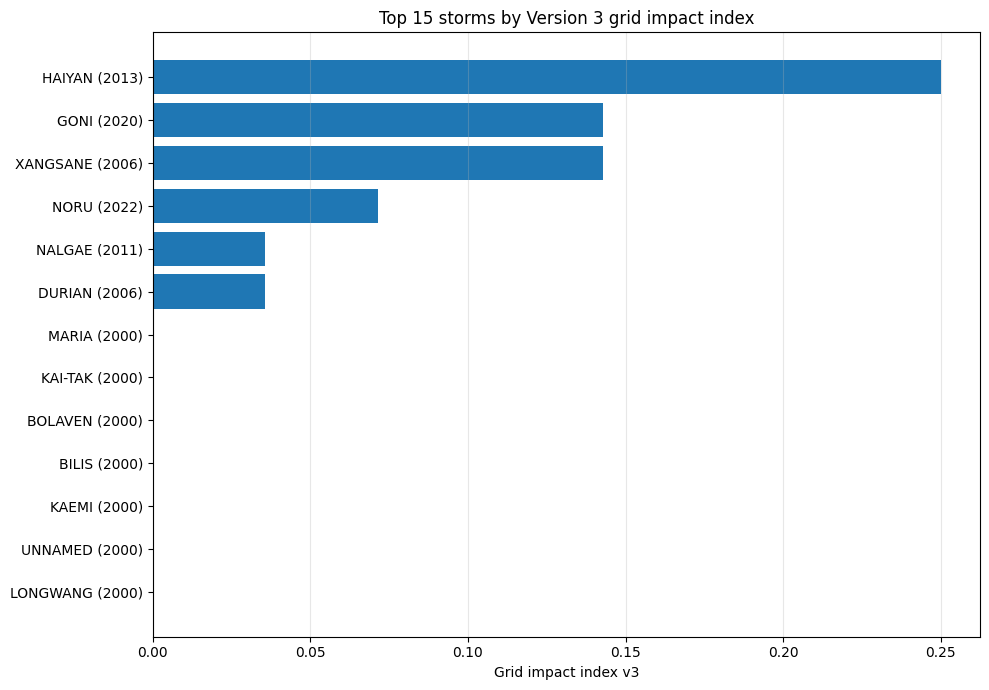

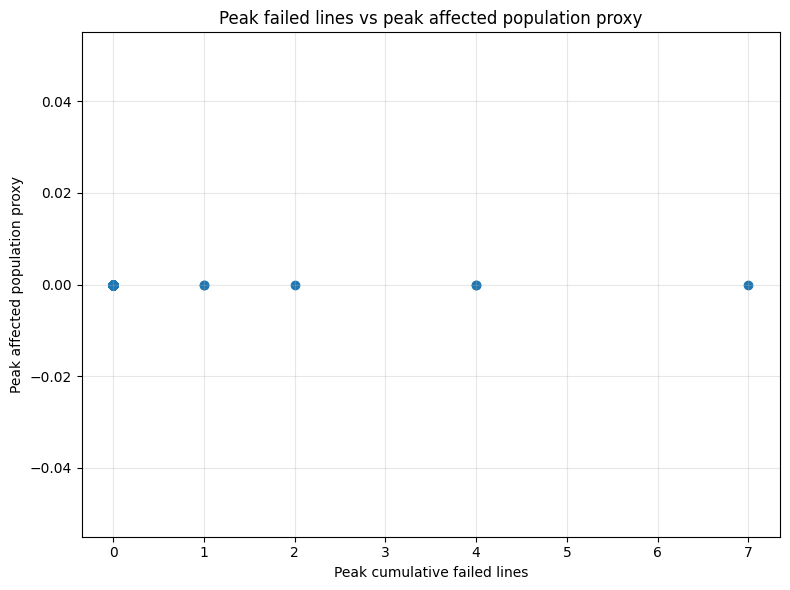

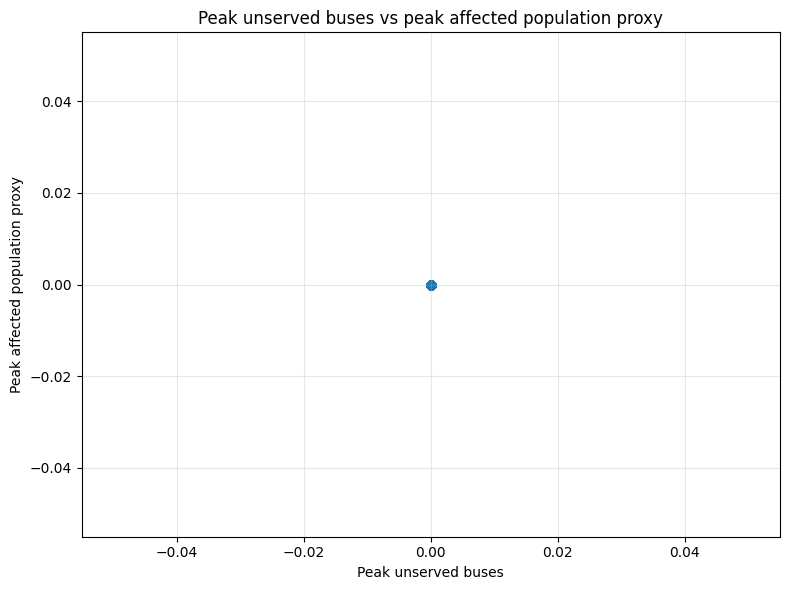

In [95]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_df = rank_df_v3.head(15).sort_values("grid_impact_index_v3")
labels = plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")"

ax.barh(labels, plot_df["grid_impact_index_v3"])
ax.set_title("Top 15 storms by Version 3 grid impact index")
ax.set_xlabel("Grid impact index v3")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rank_df_v3["peak_n_failed_lines_cumulative"], rank_df_v3["peak_affected_population_proxy"])
ax.set_title("Peak failed lines vs peak affected population proxy")
ax.set_xlabel("Peak cumulative failed lines")
ax.set_ylabel("Peak affected population proxy")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rank_df_v3["peak_n_unserved_buses"], rank_df_v3["peak_affected_population_proxy"])
ax.set_title("Peak unserved buses vs peak affected population proxy")
ax.set_xlabel("Peak unserved buses")
ax.set_ylabel("Peak affected population proxy")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Inspect the top ranked storm dynamically**

In [96]:
top_storm_id_v3 = rank_df_v3.iloc[0]["storm_id"]
top_storm_year_v3 = int(rank_df_v3.iloc[0]["year"])

gen_buses_top_v3 = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=top_storm_year_v3,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_top_v3, steps_top_v3 = simulate_grid_impact_timeseries_v3(
    storm_id=top_storm_id_v3,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses,
    G_base=G_base,
    gen_buses=gen_buses_top_v3,
    decay_km=DECAY_KM,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
)

display(ts_top_v3)

top_gif_v3 = OUTPUT_DIR / f"storm_animation_top_v3_{top_storm_id_v3}.gif"

anim_top_v3 = animate_storm_impact(
    step_outputs=steps_top_v3,
    out_gif_path=top_gif_v3,
    interval=700,
)

HTML(anim_top_v3.to_jshtml())

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,max_line_hazard_this_step
0,WP312013,HAIYAN,2013,0,1,0,0.000000,0,0.0,0.0,0.0,1,0.010275
1,WP312013,HAIYAN,2013,1,2,7,0.029661,0,0.0,0.0,0.0,7,0.789933
2,WP312013,HAIYAN,2013,2,3,7,0.029661,0,0.0,0.0,0.0,7,0.789933
3,WP312013,HAIYAN,2013,3,4,7,0.029661,0,0.0,0.0,0.0,7,0.789933
4,WP312013,HAIYAN,2013,4,5,7,0.029661,0,0.0,0.0,0.0,7,0.789933
5,WP312013,HAIYAN,2013,5,6,7,0.029661,0,0.0,0.0,0.0,7,0.789933


Saved animation to: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_top_v3_WP312013.gif


**Export**

In [97]:
out_csv_v3 = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v3_sampled_lines.csv"
rank_df_v3.to_csv(out_csv_v3, index=False)

for sid, ts_df_v3 in storm_ts_store_v3.items():
    ts_path_v3 = OUTPUT_DIR / f"storm_timeseries_v3_{sid}.csv"
    ts_df_v3.to_csv(ts_path_v3, index=False)

print("Saved Version 3 ranking:", out_csv_v3.resolve())
print("Saved Version 3 per-storm timeseries CSVs to:", OUTPUT_DIR.resolve())

Saved Version 3 ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v3_sampled_lines.csv
Saved Version 3 per-storm timeseries CSVs to: /home/krawalker/coding/KRITIS-PH/outputs


## Limitations

This screening model is intentionally stylized. It does not represent:
- full AC/DC power flow
- line loading, generation adequacy, or dispatch
- probabilistic fragility
- restoration dynamics
- historical infrastructure build-out by event year

Results should therefore be interpreted as **comparative benchmark stress tests**, not literal outage reconstructions.